In [1]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Callable, Dict, Tuple, List, Optional, Iterable, Any
import heapq
import math
import networkx as nx
from typing import Callable, Iterable, Dict, List, Optional
import matplotlib.pyplot as plt
from typing import Set, Tuple, Optional, List, Dict, Iterable
import random
import numpy as np
import seaborn as sns
import pandas as pd
from collections import Counter
import matplotlib as mpl
import matplotlib.patheffects as pe
import os
import re


figpath = os.path.join("fig_exp3")
exppath = os.path.join("..","experiment","exp3_problems")


# ---------- Problem specification ----------

CityName = str
History = int  # bitmask over tracked "trigger" cities

@dataclass(frozen=True)
class City:
    virus: float
    q_cost_per_day: float
    # rule(history, from_city, to_city) -> quarantine_days_in_to_city
    quarantine_rule: Callable[[History, CityName, CityName], int]

@dataclass(frozen=True)
class Flight:
    duration: float
    cost: float

@dataclass(frozen=True)
class Weights:
    w_time: float
    w_cost: float
    w_exposure: float

@dataclass
class CovidNavProblem:
    cities: Dict[CityName, City]
    # adjacency: flights[u][v] = Flight(...)
    flights: Dict[CityName, Dict[CityName, Flight]]
    # which cities are tracked in history bitmask (e.g., "risky cities")
    tracked: List[CityName]

    def tracked_index(self) -> Dict[CityName, int]:
        return {c: i for i, c in enumerate(self.tracked)}


# ---------- Helpers to build rules ----------

from typing import Callable, Iterable, Optional, List, Dict

# A "clause" returns a candidate quarantine day count (0 means "doesn't apply").
QuarantineClause = Callable[[History, CityName, CityName], int]

def compose_quarantine_rule(
    base_days: int,
    clauses: Iterable[QuarantineClause],
    combine: str = "max",
) -> Callable[[History, CityName, CityName], int]:
    """
    Build a quarantine_rule(history, from_city, to_city) -> days
    from a base and multiple if-clauses.

    combine="max" implements OR semantics: take the strictest requirement.
    """
    clauses = list(clauses)

    if combine != "max":
        raise ValueError("Only combine='max' is implemented (recommended for OR semantics).")

    def rule(history: History, frm: CityName, to: CityName) -> int:
        best = base_days
        for cl in clauses:
            d = cl(history, frm, to)
            if d > best:
                best = d
        return best

    return rule

def fixed_quarantine(days: int) -> Callable[[History, CityName, CityName], int]:
    def rule(history: History, frm: CityName, to: CityName) -> int:
        return days
    return rule

def quarantine_if_visited(trigger_cities: Iterable[CityName], days: int, problem: CovidNavProblem):
    """
    Quarantine in 'to' city if ANY trigger city has been visited earlier (including current city if you want).
    Uses the problem.tracked bitmask.
    """
    trig = set(trigger_cities)
    idx = problem.tracked_index()
    trig_mask = 0
    for c in trig:
        if c not in idx:
            raise ValueError(f"Trigger city {c} must be in problem.tracked to use bitmask history.")
        trig_mask |= (1 << idx[c])

    def rule(history: History, frm: CityName, to: CityName) -> int:
        return days if (history & trig_mask) != 0 else 0

    return rule

def clause_if_visited(trigger_cities: Iterable[CityName], promoted_days: int, problem: CovidNavProblem) -> QuarantineClause:
    """
    If ANY trigger city has been visited earlier (per bitmask history),
    return promoted_days, else 0.
    """
    trig = set(trigger_cities)
    idx = problem.tracked_index()

    trig_mask = 0
    for c in trig:
        if c not in idx:
            raise ValueError(f"Trigger city {c} must be in problem.tracked to use bitmask history.")
        trig_mask |= (1 << idx[c])

    def clause(history: History, frm: CityName, to: CityName) -> int:
        return promoted_days if (history & trig_mask) != 0 else 0

    return clause

def clause_if_arrive_from(x: CityName, promoted_days: int) -> QuarantineClause:
    """
    If arriving directly from city x, return promoted_days, else 0.
    """
    def clause(history: History, frm: CityName, to: CityName) -> int:
        return promoted_days if frm == x else 0
    return clause

# ---------- History update ----------

def update_history(history: History, city: CityName, idx: Dict[CityName, int]) -> History:
    if city in idx:
        return history | (1 << idx[city])
    return history


# ---------- Cost model ----------

def step_cost(
    problem: CovidNavProblem,
    weights: Weights,
    frm: CityName,
    to: CityName,
    history: History,
) -> Tuple[float, Dict[str, float], int]:
    """
    Returns:
      (scalar_loss_increment, components_dict, quarantine_days_in_to)
    components_dict includes time, cost, exposure increments (unweighted).
    """
    flight = problem.flights[frm][to]
    to_city = problem.cities[to]
    q_days = to_city.quarantine_rule(history, frm, to)

    # Unweighted components
    time_inc = flight.duration + q_days # flight time + city quarantine time
    cost_inc = flight.cost + (to_city.q_cost_per_day * q_days) # flight cost + city quarantine cost

    # Option A: exposure added once per city visit
    exposure_inc = to_city.virus
    # Option B (common): exposure scales with time spent in city (incl quarantine)
    # exposure_inc = to_city.virus * q_days

    loss_inc = (weights.w_time * time_inc) + (weights.w_cost * cost_inc) + (weights.w_exposure * exposure_inc)

    return loss_inc, {"time": time_inc, "cost": cost_inc, "exposure": exposure_inc}, q_days


# ---------- Dijkstra over expanded state space ----------

State = Tuple[CityName, History]

@dataclass
class SolveResult:
    best_loss: float
    dist: Dict[State, float]
    parents: Dict[State, List[State]]  # all optimal predecessors
    goal_states: List[State]  # all (goal, history) with best_loss

def dijkstra_expanded(problem: CovidNavProblem, start: CityName, goal: CityName, weights: Weights) -> SolveResult:
    idx = problem.tracked_index()

    start_hist = update_history(0, start, idx)
    start_state: State = (start, start_hist)

    dist: Dict[State, float] = {start_state: 0.0}
    parents: Dict[State, List[State]] = {start_state: []}

    pq = [(0.0, start_state)]
    best_goal = math.inf
    goal_states: List[State] = []

    while pq:
        d, (u, h) = heapq.heappop(pq)
        if d != dist.get((u, h), math.inf):
            continue

        if d > best_goal:
            # We've already found goal; remaining are worse
            break

        if u == goal:
            if d < best_goal - 1e-12:
                best_goal = d
                goal_states = [(u, h)]
            elif abs(d - best_goal) <= 1e-12:
                goal_states.append((u, h))
            continue

        for v in problem.flights[u].keys():
            inc, _, _ = step_cost(problem, weights, u, v, h)
            h2 = update_history(h, v, idx)
            s2: State = (v, h2)
            nd = d + inc

            cur = dist.get(s2, math.inf)
            if nd < cur - 1e-12:
                dist[s2] = nd
                parents[s2] = [(u, h)]
                heapq.heappush(pq, (nd, s2))
            elif abs(nd - cur) <= 1e-12:
                parents.setdefault(s2, []).append((u, h))

    return SolveResult(best_loss=best_goal, dist=dist, parents=parents, goal_states=goal_states)


# ---------- Reconstruct / enumerate optimal paths ----------

def enumerate_optimal_paths(result: SolveResult, start: CityName, goal: CityName, limit: int = 1000) -> List[List[State]]:
    # gather all optimal goal states
    goals = result.goal_states
    if not goals or math.isinf(result.best_loss):
        return []

    paths: List[List[State]] = []

    # backtrack DFS from each optimal goal state, using parent lists
    def backtrack(s: State, acc: List[State]):
        if len(paths) >= limit:
            return
        acc.append(s)
        if result.parents.get(s) == []:
            # reached start_state
            paths.append(list(reversed(acc)))
        else:
            for p in result.parents.get(s, []):
                backtrack(p, acc)
        acc.pop()

    for g in goals:
        backtrack(g, [])
        if len(paths) >= limit:
            break

    # (Optional) filter only those whose first city matches `start`
    paths = [p for p in paths if p and p[0][0] == start and p[-1][0] == goal]
    return paths


# ---------- Evaluate a proposed itinerary ----------

def itinerary_loss(problem: CovidNavProblem, weights: Weights, itinerary: List[CityName]) -> float:
    idx = problem.tracked_index()
    h = 0
    h = update_history(h, itinerary[0], idx)
    total = 0.0
    for frm, to in zip(itinerary[:-1], itinerary[1:]):
        inc, _, _ = step_cost(problem, weights, frm, to, h)
        total += inc
        h = update_history(h, to, idx)
    return total



def add_bidirectional_flight(problem: CovidNavProblem, a: str, b: str, duration: float, cost: float):
    problem.flights.setdefault(a, {})[b] = Flight(duration=duration, cost=cost)
    problem.flights.setdefault(b, {})[a] = Flight(duration=duration, cost=cost)

def rule_arrive_from(x: str, days: int):
    # quarantine depends only on where you came from
    def rule(history: int, frm: str, to: str) -> int:
        return days if frm == x else 0
    return rule


def pretty_city_path(state_path):
    # state_path is [(city, historybitmask), ...]
    return [city for (city, h) in state_path]

def draw_problem_graph(
    problem,
    start=None,
    goal=None,
    optimal_city_path=None,   # e.g., ["StartTown","A","SafeTown","GoalCity"]
    node_rule_text=None,      # dict city->string to display quarantine rule nicely (recommended)
    figsize=(8, 8),
    layout="spring",          # "spring" | "kamada_kawai" | "shell"
    seed=7,
):
    """
    Visualize the city-flight graph with node/edge attribute boxes and (optionally) highlight an optimal path.

    Parameters
    ----------
    problem : CovidNavProblem
        Problem object (cities + flights).
    start, goal : str | None
        Cities to emphasize in labels.
    optimal_city_path : list[str] | None
        Sequence of city names representing an itinerary to highlight.
    node_rule_text : dict[str,str] | None
        Human-readable rule descriptions to display for each city.
        (Because arbitrary Python callables are hard to pretty-print.)
    """
    # ---- build a NetworkX graph (undirected) ----
    G = nx.Graph()
    for city, cobj in problem.cities.items():
        G.add_node(city)

    for u, nbrs in problem.flights.items():
        for v, flight in nbrs.items():
            # Because storage is bidirectional, avoid double-adding
            if G.has_edge(u, v):
                continue
            G.add_edge(u, v, duration=flight.duration, cost=flight.cost)

    # ---- choose layout ----
    if layout == "kamada_kawai":
        pos = nx.kamada_kawai_layout(G)
    elif layout == "shell":
        pos = nx.shell_layout(G)
    else:
        pos = nx.spring_layout(G, seed=seed)

    # ---- compute which edges are on the highlighted path ----
    path_edges = set()
    if optimal_city_path and len(optimal_city_path) >= 2:
        for a, b in zip(optimal_city_path[:-1], optimal_city_path[1:]):
            # graph is undirected; normalize
            path_edges.add(tuple(sorted((a, b))))

    # ---- draw base nodes/edges ----
    plt.figure(figsize=figsize)
    ax = plt.gca()
    ax.set_axis_off()

    # Edges: draw non-path edges first (thin), then path edges (thick)
    non_path_edges = []
    path_edges_list = []
    for (u, v) in G.edges():
        key = tuple(sorted((u, v)))
        if key in path_edges:
            path_edges_list.append((u, v))
        else:
            non_path_edges.append((u, v))

    nx.draw_networkx_edges(G, pos, edgelist=non_path_edges, width=1.5, alpha=0.6)
    if path_edges_list:
        nx.draw_networkx_edges(G, pos, edgelist=path_edges_list, width=5.0, alpha=0.9)

    # Nodes: draw all, then optionally emphasize start/goal
    nx.draw_networkx_nodes(G, pos, node_size=1400, alpha=0.9)
    if start in G:
        nx.draw_networkx_nodes(G, pos, nodelist=[start], node_size=1900, alpha=1.0)
    if goal in G:
        nx.draw_networkx_nodes(G, pos, nodelist=[goal], node_size=1900, alpha=1.0)

    # ---- node label boxes with all node info ----
    if node_rule_text is None:
        node_rule_text = {}

    node_labels = {}
    for city, cobj in problem.cities.items():
        rule_str = node_rule_text.get(city, "(rule not provided)")
        # Make labels “big” and information-dense
        node_labels[city] = (
            f"{city}"
            + ("\n[START]" if city == start else "")
            + ("\n[GOAL]" if city == goal else "")
#             + f"\nvirus={cobj.virus:g}"
#             + f"\nq_cost/day={cobj.q_cost_per_day:g}"
            + f"\n{rule_str}"
        )

    nx.draw_networkx_labels(
        G,
        pos,
        labels=node_labels,
        font_size=8,
        verticalalignment="center",
        horizontalalignment="center",
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="black", alpha=0.85),
    )

    # ---- edge label boxes with duration/cost ----
    edge_labels = {(u, v): f"dur={G[u][v]['duration']:g}\ncost={G[u][v]['cost']:g}" for (u, v) in G.edges()}

    # Place edge labels in boxes centered on edges
    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=8,
        rotate=False,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black", alpha=0.85),
    )

    # ---- title ----
    title = "COVID Itinerary Graph"
    if optimal_city_path:
        title += f"\nHighlighted path: {' → '.join(optimal_city_path)}"
    plt.title(title)
    plt.tight_layout()
    return pos

# -------------------------
# 1) Add metadata to clause builders + compose_quarantine_rule
#    (so we can introspect rules later for plotting)
# -------------------------

QuarantineClause = Callable[[History, CityName, CityName], int]

def clause_if_visited(trigger_cities: Iterable[CityName], promoted_days: int, problem) -> QuarantineClause:
    """
    Clause: if ANY of trigger_cities has been visited (bitmask history), return promoted_days else 0.
    Requires trigger cities be in problem.tracked.
    """
    trig = list(trigger_cities)
    idx = problem.tracked_index()

    trig_mask = 0
    for c in trig:
        if c not in idx:
            raise ValueError(f"Trigger city {c} must be in problem.tracked to use bitmask history.")
        trig_mask |= (1 << idx[c])

    def clause(history: History, frm: CityName, to: CityName) -> int:
        return promoted_days if (history & trig_mask) != 0 else 0

    # ---- metadata for auto-labeling ----
    clause._qr_meta = {  # type: ignore[attr-defined]
        "type": "visited_any",
        "trigger_cities": trig,
        "promoted_days": int(promoted_days),
    }
    return clause


def clause_if_arrive_from(x: CityName, promoted_days: int) -> QuarantineClause:
    """
    Clause: if arriving directly from x, return promoted_days else 0.
    """
    def clause(history: History, frm: CityName, to: CityName) -> int:
        return promoted_days if frm == x else 0

    # ---- metadata for auto-labeling ----
    clause._qr_meta = {  # type: ignore[attr-defined]
        "type": "arrive_from",
        "from_city": x,
        "promoted_days": int(promoted_days),
    }
    return clause


def compose_quarantine_rule(
    base_days: int,
    clauses: Iterable[QuarantineClause],
    combine: str = "max",
) -> Callable[[History, CityName, CityName], int]:
    """
    quarantine_days = combine(base_days, clause1(...), clause2(...), ...)

    combine="max" implements OR semantics (strictest requirement wins).
    """
    clauses = list(clauses)

    if combine != "max":
        raise ValueError("Only combine='max' is implemented (recommended for OR semantics).")

    def rule(history: History, frm: CityName, to: CityName) -> int:
        best = int(base_days)
        for cl in clauses:
            d = int(cl(history, frm, to))
            if d > best:
                best = d
        return best

    # ---- metadata for auto-labeling ----
    rule._qr_meta = {  # type: ignore[attr-defined]
        "type": "composed",
        "combine": combine,
        "base_days": int(base_days),
        "clauses": clauses,  # keep references so we can introspect each clause's meta
    }
    return rule


# -------------------------
# 2) Auto-generate node_rule_text from the problem object's quarantine_rule callables
# -------------------------

def generate_node_rule_text(problem, multiline: bool = True) -> Dict[str, str]:
    """
    Returns dict: city_name -> human-readable quarantine rule text.

    Works best if quarantine rules were created using compose_quarantine_rule()
    and clauses were created using clause_if_visited / clause_if_arrive_from above,
    because those store metadata used for introspection.

    If metadata isn't present (older rules), it falls back to a safe placeholder.
    """

    def fmt_clause(meta: Dict) -> str:
        t = meta.get("type", "unknown")
        if t == "visited_any":
            cities = meta.get("trigger_cities", [])
            d = meta.get("promoted_days", "?")
            return f"If visited {cities[0]}: {d} days"
        if t == "arrive_from":
            x = meta.get("from_city", "?")
            d = meta.get("promoted_days", "?")
            return f"If arrive from {x}: {d} days"
        # Unknown clause type
        return f"if <{t}> → {meta.get('promoted_days','?')}"

    out: Dict[str, str] = {}

    for city, cobj in problem.cities.items():
        rule = cobj.quarantine_rule
        meta = getattr(rule, "_qr_meta", None)

        if isinstance(meta, dict) and meta.get("type") == "composed":
            base = meta.get("base_days", 0)
            combine = meta.get("combine", "Max")
            clauses: List[QuarantineClause] = meta.get("clauses", [])

            clause_texts: List[str] = []
            for cl in clauses:
                cl_meta = getattr(cl, "_qr_meta", None)
                if isinstance(cl_meta, dict):
                    clause_texts.append(fmt_clause(cl_meta))
                else:
                    # fallback: we at least signal an unnamed clause
                    clause_texts.append("If <custom clause>")

            if not clause_texts:
                out[city] = f"Base: {base} days"
            else:
                if multiline:
                    # One clause per line for readability in node box
                    out[city] = "Base: {} days\nModifying rules:\n{} \n({} days applied if multiple rules match)".format(
                        base,
                        "\n  ".join(clause_texts),
                        combine,
                    )
                else:
                    out[city] = f"Base {base}; {combine}(" + ", ".join(clause_texts) + ")"

        else:
            # Fallback for older/simple rules (e.g., fixed_quarantine)
            # Try to detect a trivial fixed rule by probing two dummy calls.
            try:
                a = rule(0, city, city)
                b = rule(123456, "X", "Y")
                if a == b:
                    out[city] = f"fixed {int(a)}"
                else:
                    out[city] = "rule: <unlabeled>"
            except Exception:
                out[city] = "rule: <unlabeled>"

    return out





best loss: 1208.0
['StartTown', 'C', 'F', 'GoalCity']


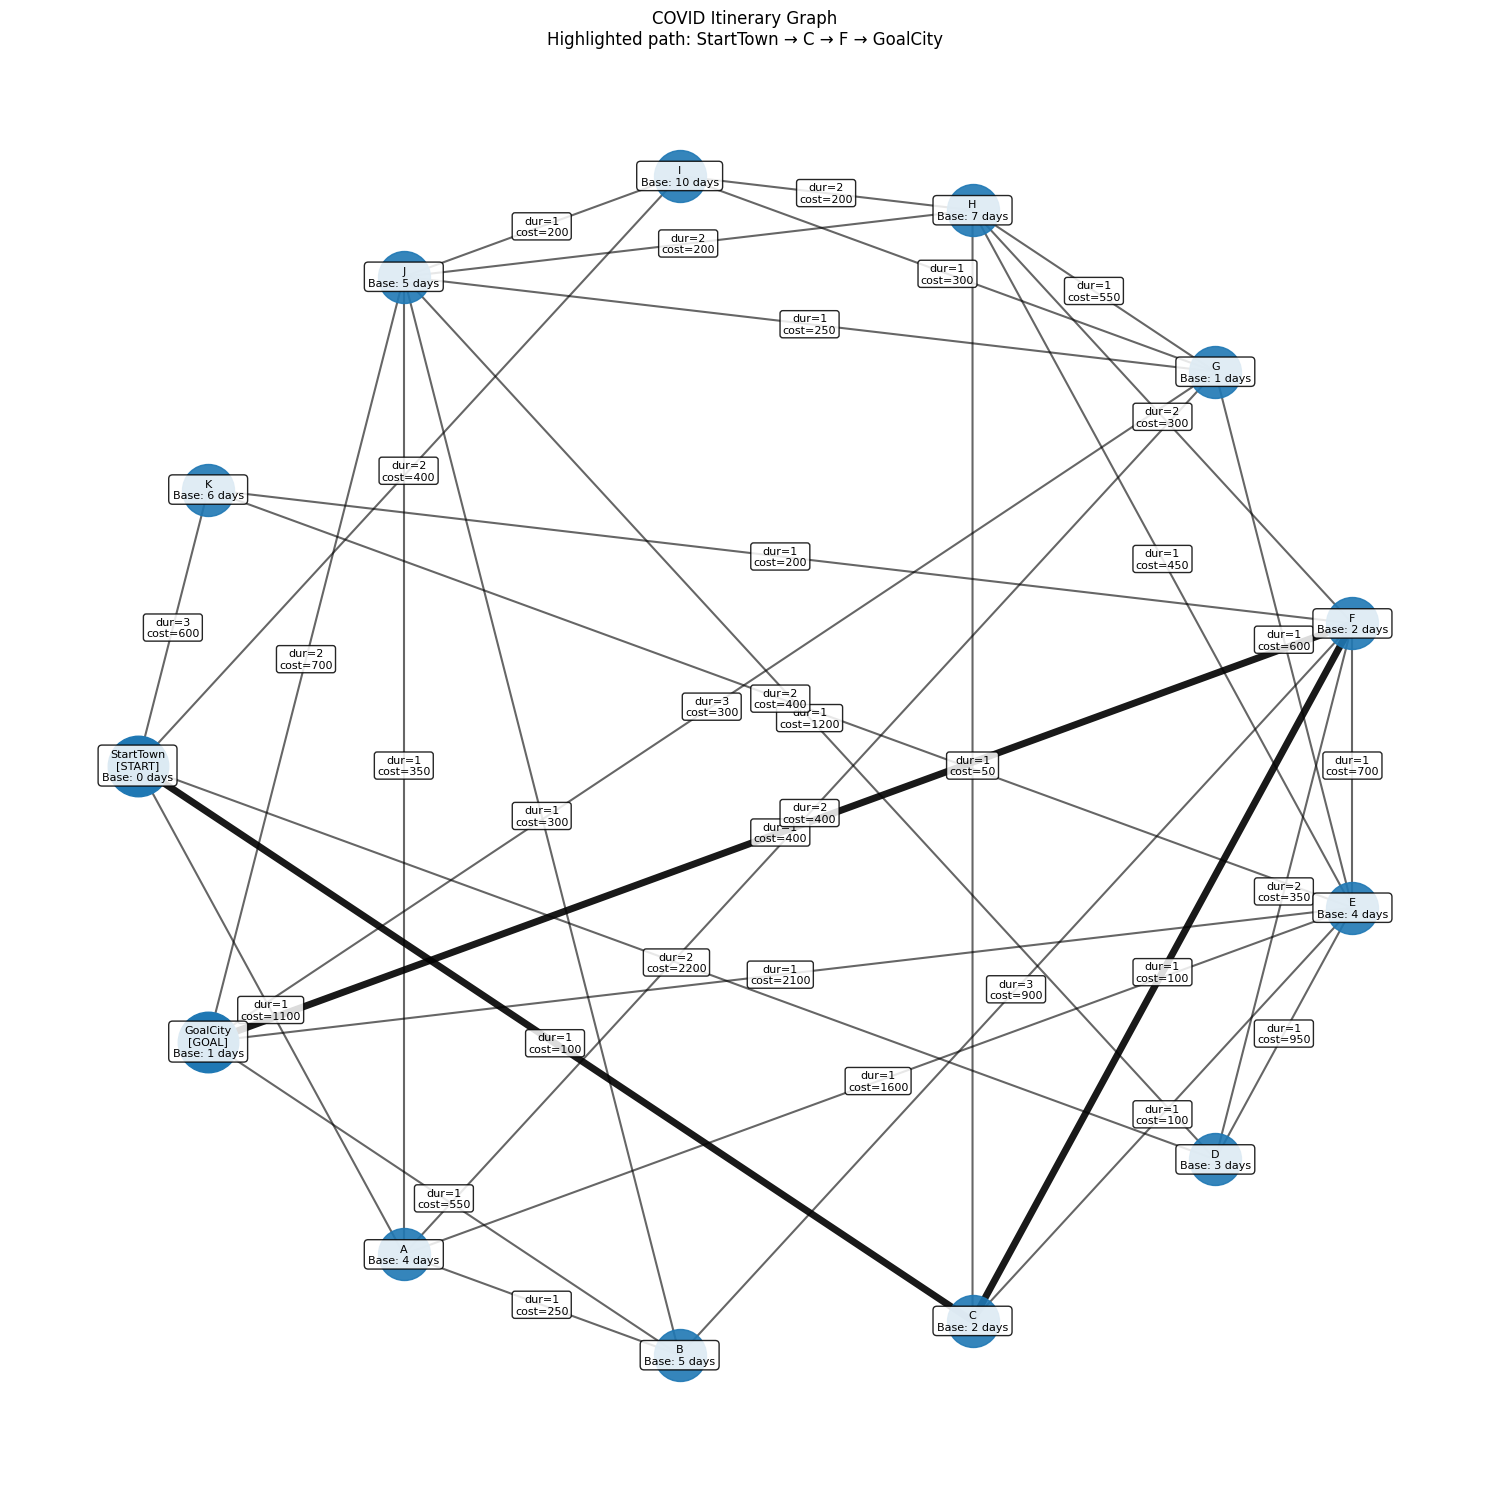

In [2]:
def make_problem():
    """
    A >10-city COVID itinerary graph with:
      - no direct StartTown -> GoalCity flight
      - fairly connected (most cities degree 3–5)
      - heterogeneous flight durations/costs so fewer hops is NOT always cheaper/faster
      - quarantine rules with base quarantine + multiple OR (max) promotion clauses

    Requires the earlier code:
      - City, Flight, CovidNavProblem, Weights
      - fixed_quarantine (ok to keep; not used much here)
      - update_history, step_cost, dijkstra_expanded, enumerate_optimal_paths, itinerary_loss
      - compose_quarantine_rule, clause_if_visited, clause_if_arrive_from
    """

    # --- helper: bidirectional flight ---
    def add2(problem: CovidNavProblem, a: str, b: str, duration: float, cost: float):
        problem.flights.setdefault(a, {})[b] = Flight(duration=duration, cost=cost)
        problem.flights.setdefault(b, {})[a] = Flight(duration=duration, cost=cost)

    # --- tracked cities for history-dependent rules (bitmask) ---
    tracked = ["C", "F", "E", "K"]

    problem = CovidNavProblem(cities={}, flights={}, tracked=tracked)

    # --- Cities (virus, quarantine cost/day, quarantine rule) ---
    # Base quarantine is usually 1 day, then "max-promoted" if conditions fire.
    # Some cities are deliberately "sticky" if you've visited risk hotspots.

    problem.cities["StartTown"] = City(
        virus=0,
        q_cost_per_day=0,
        quarantine_rule=compose_quarantine_rule(base_days=0, clauses=[]),
    )

    problem.cities["GoalCity"] = City(
        virus=0,
        q_cost_per_day=0,
        quarantine_rule=compose_quarantine_rule(
            base_days=1,
            clauses=[]
        ),
    )

    problem.cities["A"] = City(
        virus=0,
        q_cost_per_day=0,
        quarantine_rule=compose_quarantine_rule(
            base_days=4,
            clauses=[]
        ),
    )

    problem.cities["B"] = City(
        virus=0,
        q_cost_per_day=0,
        quarantine_rule=compose_quarantine_rule(
            base_days=5,
            clauses=[]
        ),
    )

    problem.cities["C"] = City(
        virus=0,
        q_cost_per_day=0,
        quarantine_rule=compose_quarantine_rule(base_days=2, clauses=[]),
    )

    problem.cities["D"] = City(
        virus=13,
        q_cost_per_day=0,
        quarantine_rule=compose_quarantine_rule(
            base_days=3,
            clauses=[]
        ),
    )

    problem.cities["E"] = City(
        virus=0,
        q_cost_per_day=0,
        quarantine_rule=compose_quarantine_rule(
            base_days=4,
            clauses=[]
        ),
    )

    problem.cities["F"] = City(
        virus=0,
        q_cost_per_day=0,
        quarantine_rule=compose_quarantine_rule(base_days=2, clauses=[]),
    )

    problem.cities["G"] = City(
        virus=0,
        q_cost_per_day=0,
        quarantine_rule=compose_quarantine_rule(
            base_days=1, # change from 1 to 5 to change optimal solution
            clauses=[]
        ),
    )

    problem.cities["H"] = City(
        virus=0,
        q_cost_per_day=0,
        quarantine_rule=compose_quarantine_rule(
            base_days=7,
            clauses=[]
        ),
    )

    problem.cities["I"] = City(
        virus=0,
        q_cost_per_day=0,
        quarantine_rule=compose_quarantine_rule(base_days=10, clauses=[]), # change from 1 to 10 to change the optimal sol
    )

    problem.cities["J"] = City(
        virus=0,
        q_cost_per_day=0,
        quarantine_rule=compose_quarantine_rule(
            base_days=5,
            clauses=[]
        ),
    )

    problem.cities["K"] = City(
        virus=0,
        q_cost_per_day=0,
        quarantine_rule=compose_quarantine_rule(
            base_days=6,
            clauses=[]
        ),
    )

    # --- Flights (duration, cost) ---
    # Design intent:
    #  - some “short hop” routes are very expensive (few edges but high cost)
    #  - some longer routes are cheap but time-consuming (more edges but lower cost)
    #  - some routes pass through risky cities (high exposure + downstream quarantine penalties)
    #
    # No direct StartTown <-> GoalCity edge.

    # From StartTown: multiple options (one pricey-fast, one cheap-risky, one moderate)
    add2(problem, "StartTown", "A",   duration=1, cost=1100.0)  # reasonable
    add2(problem, "StartTown", "D",    duration=2, cost=2200.0)  # fast but expensive
    #add2(problem, "StartTown", "E",    duration=3, cost=210.0)  # Newly added from covid_flight_lab2; enables a 2-step solution
    add2(problem, "StartTown", "K",    duration=3, cost=600.0)  # Newly added from covid_flight_lab2; enables a 2-step solution
    add2(problem, "StartTown", "I",  duration=2, cost=400.0)   # slower but cheap
    add2(problem, "StartTown", "C", duration=1, cost=100.0)    # very cheap but triggers quarantines + exposure

    # Core mid-graph connections (fairly connected)
    add2(problem, "A",  "B",  duration=1, cost=250.0)
    add2(problem, "A",  "J",    duration=1, cost=350.0)
    add2(problem, "A",  "E",    duration=1, cost=1600.0)  # short but expensive
    add2(problem, "A",  "G",  duration=2, cost=400.0)

    add2(problem, "I", "G",  duration=1, cost=300.0)
    add2(problem, "I", "J",    duration=1, cost=200.0)
    add2(problem, "I", "H",    duration=2, cost=200.0)   # long but cheap

    add2(problem, "D",   "J",    duration=1, cost=1200.0)  # fast-ish, pricey
    add2(problem, "D",   "E",    duration=1, cost=950.0)
    add2(problem, "D",   "F", duration=2, cost=350.0)   # moderate, cheap (but F is risky)

    add2(problem, "J",   "G",  duration=1, cost=250.0)
    add2(problem, "J",   "H",    duration=2, cost=200.0)
    add2(problem, "J",   "B",  duration=1, cost=300.0)

    add2(problem, "G", "H",    duration=1, cost=550.0)   # short but more expensive than alternatives
    add2(problem, "G", "E",    duration=1, cost=600.0)

    add2(problem, "H",   "E",    duration=1, cost=450.0)
    add2(problem, "H",   "F", duration=2, cost=300.0)   # longer but cheap (risk city)

    # Risk / coastal subgraph (tempting cheap flights but carries exposure + quarantine cascades)
    add2(problem, "C", "E",   duration=1, cost=100.0)
    add2(problem, "C", "F",duration=1, cost=100.0)
    add2(problem, "C", "H",   duration=1, cost=50.0)

    add2(problem, "F", "K",   duration=1, cost=200.0)
    add2(problem, "K",    "E",   duration=2, cost=400.0)
    add2(problem, "F", "E",   duration=1, cost=700.0)
    add2(problem, "F", "B", duration=3, cost=900.0)

    # Paths toward GoalCity (multiple “funnels”)
    add2(problem, "B", "GoalCity",  duration=1, cost=550.0)   # classic “safe funnel”
    add2(problem, "E",   "GoalCity",  duration=1, cost=2100.0)  # short but expensive + quarantine-prone
    add2(problem, "J",   "GoalCity",  duration=2, cost=700.0)
    add2(problem, "G", "GoalCity",  duration=3, cost=300.0)   # long but cheap (often good if time weight small)
    add2(problem, "F","GoalCity",  duration=1, cost=400.0)   # moderate but risky (quarantine promotions)

    return problem


# --- Example usage (optional) ---
problem = make_problem()
weights = Weights(w_time=1, w_cost=2, w_exposure=0)
start, goal = "StartTown", "GoalCity"
result = dijkstra_expanded(problem, start, goal, weights)
opt_paths = enumerate_optimal_paths(result, start, goal, limit=20)
best_path = [city for (city, h) in opt_paths[0]]  # pick one optimal itinerary

print("best loss:", result.best_loss)
for p in opt_paths[:5]:
    print([city for city, h in p])
    
# 3) Draw the graph with the optimal path highlighted
node_rule_text = generate_node_rule_text(problem, multiline=True)
pos = draw_problem_graph(problem, start=start, goal=goal, optimal_city_path=best_path, node_rule_text=node_rule_text, 
                   figsize=(15,15),    
                   layout="shell",          # "spring" | "kamada_kawai" | "shell"
                   seed=0,)
#plt.savefig(os.path.join(figpath, "exp3_exampletrial"), dpi=300)
plt.show()
    


## Create many trials by shuffling the problem features


In [3]:
# Create many trials by shuffling the problem features


from __future__ import annotations
from dataclasses import dataclass
from typing import Dict, List, Tuple, Iterable, Optional, Any
import copy
import random

# Assumes these exist from earlier:
# - City, Flight, CovidNavProblem
# - compose_quarantine_rule, clause_if_visited, clause_if_arrive_from
# - (optional) fixed_quarantine
# And that compose_quarantine_rule / clause_* attach _qr_meta metadata.

CityName = str
History = int


def _get_rule_meta(rule) -> Optional[dict]:
    meta = getattr(rule, "_qr_meta", None)
    return meta if isinstance(meta, dict) else None


def _rebuild_rule_from_meta(city: str, meta: dict, new_base: int, new_clause_days: List[int], problem: CovidNavProblem):
    """
    Rebuild a composed quarantine rule with same clause structure but new day parameters.
    new_clause_days must match number of clauses in meta['clauses'].
    """
    assert meta.get("type") == "composed"
    clauses_old = meta.get("clauses", [])
    if len(clauses_old) != len(new_clause_days):
        raise ValueError(f"[{city}] mismatch: {len(clauses_old)} clauses but {len(new_clause_days)} new days.")

    clauses_new = []
    for cl_old, d_new in zip(clauses_old, new_clause_days):
        clm = getattr(cl_old, "_qr_meta", None)
        if not isinstance(clm, dict):
            # If clause meta missing, keep the old clause as-is (can't safely rebuild)
            clauses_new.append(cl_old)
            continue

        t = clm.get("type")
        if t == "visited_any":
            triggers = clm.get("trigger_cities", [])
            clauses_new.append(clause_if_visited(triggers, promoted_days=int(d_new), problem=problem))
        elif t == "arrive_from":
            x = clm.get("from_city")
            clauses_new.append(clause_if_arrive_from(x, promoted_days=int(d_new)))
        else:
            # Unknown clause type: keep old clause (or raise). Keeping is safer.
            clauses_new.append(cl_old)

    return compose_quarantine_rule(base_days=int(new_base), clauses=clauses_new, combine=meta.get("combine", "max"))


def _iter_undirected_edges(problem: CovidNavProblem) -> List[Tuple[str, str]]:
    """
    Return each undirected edge once as a sorted tuple (u,v).
    Assumes flights are bidirectional in storage.
    """
    seen = set()
    edges = []
    for u, nbrs in problem.flights.items():
        for v in nbrs.keys():
            key = tuple(sorted((u, v)))
            if key in seen:
                continue
            seen.add(key)
            edges.append(key)
    return edges

Edge = Tuple[str, str]  # undirected edge key (u,v) sorted


def _norm_edge(u: str, v: str) -> Edge:
    return (u, v) if u <= v else (v, u)


# ============================================================
# PROBLEM UNIQUENESS + VALIDITY HELPERS
# ============================================================

def problem_fingerprint(problem: CovidNavProblem):
    """
    Create a canonical immutable representation of all feature values.
    Used to detect duplicate problems.
    """

    # ---- cities ----
    city_items = []
    for c in sorted(problem.cities.keys()):
        city = problem.cities[c]

        meta = _get_rule_meta(city.quarantine_rule)
        if meta and meta.get("type") == "composed":
            base_days = int(meta.get("base_days", 0))

            clause_days = []
            for cl in meta.get("clauses", []):
                clm = getattr(cl, "_qr_meta", None)
                if isinstance(clm, dict) and "promoted_days" in clm:
                    clause_days.append(int(clm["promoted_days"]))
                else:
                    clause_days.append(None)

            rule_repr = ("composed", base_days, tuple(clause_days))
        else:
            rule_repr = ("other",)

        city_items.append((
            c,
            float(city.virus),
            float(city.q_cost_per_day),
            rule_repr,
        ))

    # ---- flights (undirected once) ----
    edge_items = []
    for (u, v) in sorted(_iter_undirected_edges(problem)):
        f = problem.flights[u][v]
        edge_items.append((u, v, float(f.duration), float(f.cost)))

    return (tuple(city_items), tuple(edge_items))


def has_redundant_quarantine(problem: CovidNavProblem) -> bool:
    """
    Returns True if any city has base_days == promoted_days in a clause.
    """
    for city_name, city in problem.cities.items():
        meta = _get_rule_meta(city.quarantine_rule)
        if not meta or meta.get("type") != "composed":
            continue

        base = int(meta.get("base_days", 0))

        for cl in meta.get("clauses", []):
            clm = getattr(cl, "_qr_meta", None)
            if isinstance(clm, dict) and "promoted_days" in clm:
                if int(clm["promoted_days"]) == base:
                    return True

    return False

def shuffle_problem_values(
    base_problem: CovidNavProblem,
    seed: Optional[int] = None,
    mode: str = "within_feature",  # "within_feature" | "bundle"
    shuffle_quarantine_days: bool = True,
    shuffle_city_virus: bool = True,
    shuffle_city_qcost: bool = True,
    shuffle_flight_cost: bool = True,
    shuffle_flight_duration: bool = True,
    exclude_cities: Optional[Iterable[str]] = None,
    exclude_edges: Optional[Iterable[Tuple[str, str]]] = None,
) -> CovidNavProblem:
    """
    Create ONE new problem with same topology but shuffled values, with optional exclusions.

    Exclusions:
      - exclude_cities: city names whose virus/q_cost_per_day AND quarantine day-params
        (base_days + clause promoted_days) do NOT get shuffled.
      - exclude_edges: undirected edge pairs (u,v) whose duration/cost do NOT get shuffled.

    mode:
      - "within_feature": shuffle each numeric feature independently across eligible entities
      - "bundle": shuffle (duration,cost) pairs across eligible edges; shuffle (virus,q_cost/day) pairs across eligible cities
                quarantine days are shuffled as one pool across eligible day-params if enabled
    """
    rng = random.Random(seed)

    exc_cities: Set[str] = set(exclude_cities or [])
    exc_edges: Set[Edge] = {_norm_edge(u, v) for (u, v) in (exclude_edges or [])}

    # --- Create empty same-topology shell ---
    new_problem = CovidNavProblem(cities={}, flights={}, tracked=list(base_problem.tracked))
    city_names = list(base_problem.cities.keys())

    # Copy cities (values overwritten later as needed)
    for name in city_names:
        c = base_problem.cities[name]
        new_problem.cities[name] = City(
            virus=c.virus,
            q_cost_per_day=c.q_cost_per_day,
            quarantine_rule=c.quarantine_rule,  # may rebuild later
        )

    # Copy flight structure
    for u, nbrs in base_problem.flights.items():
        new_problem.flights.setdefault(u, {})
        for v in nbrs.keys():
            new_problem.flights[u][v] = base_problem.flights[u][v]  # overwritten later

    # ---------- 1) Flights ----------
    edges_all = _iter_undirected_edges(base_problem)
    edges_free = [e for e in edges_all if e not in exc_edges]
    edges_fixed = [e for e in edges_all if e in exc_edges]

    # Start by setting fixed edges exactly as base
    for (u, v) in edges_fixed:
        f = base_problem.flights[u][v]
        new_problem.flights[u][v] = Flight(duration=float(f.duration), cost=float(f.cost))
        new_problem.flights[v][u] = Flight(duration=float(f.duration), cost=float(f.cost))

    if mode not in ("within_feature", "bundle"):
        raise ValueError("mode must be 'within_feature' or 'bundle'.")

    if edges_free:
        if mode == "bundle":
            # Shuffle (duration,cost) as a pair across FREE edges
            edge_pairs = [(base_problem.flights[u][v].duration, base_problem.flights[u][v].cost) for (u, v) in edges_free]
            rng.shuffle(edge_pairs)
            for (u, v), (dur, cost) in zip(edges_free, edge_pairs):
                new_problem.flights[u][v] = Flight(duration=float(dur), cost=float(cost))
                new_problem.flights[v][u] = Flight(duration=float(dur), cost=float(cost))
        else:
            # Shuffle duration/cost independently across FREE edges
            durs = [base_problem.flights[u][v].duration for (u, v) in edges_free]
            costs = [base_problem.flights[u][v].cost for (u, v) in edges_free]

            if shuffle_flight_duration:
                rng.shuffle(durs)
            if shuffle_flight_cost:
                rng.shuffle(costs)

            for i, (u, v) in enumerate(edges_free):
                new_problem.flights[u][v] = Flight(duration=float(durs[i]), cost=float(costs[i]))
                new_problem.flights[v][u] = Flight(duration=float(durs[i]), cost=float(costs[i]))

    # ---------- 2) City virus / q_cost_per_day ----------
    cities_free = [c for c in city_names if c not in exc_cities]
    cities_fixed = [c for c in city_names if c in exc_cities]

    # Fixed cities copied exactly already; we’ll overwrite only free ones below.
    if cities_free:
        if mode == "bundle":
            city_pairs = [(base_problem.cities[c].virus, base_problem.cities[c].q_cost_per_day) for c in cities_free]
            rng.shuffle(city_pairs)
            for c, (virus, qcost) in zip(cities_free, city_pairs):
                old = new_problem.cities[c]
                new_problem.cities[c] = City(
                    virus=float(virus),
                    q_cost_per_day=float(qcost),
                    quarantine_rule=old.quarantine_rule,
                )
        else:
            viruses = [base_problem.cities[c].virus for c in cities_free]
            qcosts  = [base_problem.cities[c].q_cost_per_day for c in cities_free]

            if shuffle_city_virus:
                rng.shuffle(viruses)
            if shuffle_city_qcost:
                rng.shuffle(qcosts)

            for i, c in enumerate(cities_free):
                old = new_problem.cities[c]
                new_problem.cities[c] = City(
                    virus=float(viruses[i]),
                    q_cost_per_day=float(qcosts[i]),
                    quarantine_rule=old.quarantine_rule,
                )

    # ---------- 3) Quarantine day parameters (base + promoted), with exclusions ----------
    if shuffle_quarantine_days:
        day_slots = []   # (city, "base", None) or (city, "clause", clause_idx)
        day_values = []
        composed_metas: Dict[str, dict] = {}

        for c in cities_free:  # IMPORTANT: only shuffle day-params for non-excluded cities
            meta = _get_rule_meta(base_problem.cities[c].quarantine_rule)
            if meta and meta.get("type") == "composed":
                composed_metas[c] = meta

                # base day
                day_slots.append((c, "base", None))
                day_values.append(int(meta.get("base_days", 0)))

                # clause promoted days (only those we can introspect)
                clauses = meta.get("clauses", [])
                for j, cl in enumerate(clauses):
                    clm = getattr(cl, "_qr_meta", None)
                    if isinstance(clm, dict) and "promoted_days" in clm:
                        day_slots.append((c, "clause", j))
                        day_values.append(int(clm["promoted_days"]))

        rng.shuffle(day_values)

        per_city_base: Dict[str, int] = {}
        per_city_clause_days: Dict[str, Dict[int, int]] = {}

        for (slot, val) in zip(day_slots, day_values):
            c, kind, j = slot
            if kind == "base":
                per_city_base[c] = int(val)
            else:
                per_city_clause_days.setdefault(c, {})[int(j)] = int(val)

        # rebuild rules for cities_free where we have meta
        for c, meta in composed_metas.items():
            base_new = per_city_base.get(c, int(meta.get("base_days", 0)))
            clauses = meta.get("clauses", [])

            clause_days_new: List[int] = []
            for j, cl in enumerate(clauses):
                clm = getattr(cl, "_qr_meta", None)
                if isinstance(clm, dict) and "promoted_days" in clm:
                    clause_days_new.append(per_city_clause_days.get(c, {}).get(j, int(clm["promoted_days"])))
                else:
                    clause_days_new.append(0)  # placeholder; unknown clauses preserved by _rebuild_rule_from_meta

            new_rule = _rebuild_rule_from_meta(c, meta, new_base=base_new, new_clause_days=clause_days_new, problem=new_problem)

            old_city = new_problem.cities[c]
            new_problem.cities[c] = City(
                virus=old_city.virus,
                q_cost_per_day=old_city.q_cost_per_day,
                quarantine_rule=new_rule,
            )

        # For excluded cities, keep quarantine_rule exactly as base (already true),
        # but to be explicit (and robust to earlier overwrites), restore them:
        for c in cities_fixed:
            base_city = base_problem.cities[c]
            old_city = new_problem.cities[c]
            new_problem.cities[c] = City(
                virus=old_city.virus,
                q_cost_per_day=old_city.q_cost_per_day,
                quarantine_rule=base_city.quarantine_rule,
            )

    return new_problem

def generate_shuffled_trials(
    base_problem: CovidNavProblem,
    N: int,
    seed: Optional[int] = None,
    mode: str = "within_feature",
    exclude_cities: Optional[Iterable[str]] = None,
    exclude_edges: Optional[Iterable[Tuple[str, str]]] = None,
    enforce_unique: bool = False,
    reject_redundant_quarantine: bool = False,
    max_resample_attempts: int = 1000,

    **kwargs,
) -> List[CovidNavProblem]:
    """
    Generate N shuffled problems with optional constraints.

    New options
    ----------
    enforce_unique:
        Ensures no two generated problems have identical feature assignments.

    reject_redundant_quarantine:
        Reject problems where a city's base quarantine equals a clause's days.

    max_resample_attempts:
        Safety bound to avoid infinite loops if constraints impossible.
    """

    if N <= 0:
        return []

    rng = random.Random(seed)
    problems = []

    seen = set()  # fingerprints

    for trial_idx in range(N):

        accepted = False
        attempts = 0

        while not accepted:

            if attempts > max_resample_attempts:
                raise RuntimeError(
                    f"Failed to generate valid problem after {max_resample_attempts} attempts.\n"
                    "Constraints may be too strict."
                )

            # generate candidate
            s = rng.randint(0, 10**9) if seed is not None else None

            prob = shuffle_problem_values(
                base_problem,
                seed=s,
                mode=mode,
                exclude_cities=exclude_cities,
                exclude_edges=exclude_edges,
                **kwargs,
            )

            attempts += 1

            # ----- constraint: redundant quarantine -----
            if reject_redundant_quarantine:
                if has_redundant_quarantine(prob):
                    continue

            # ----- constraint: uniqueness -----
            if enforce_unique:
                fp = problem_fingerprint(prob)
                if fp in seen:
                    print("Identical trial sampled. Resampling.")
                    continue
                seen.add(fp)

            accepted = True
            problems.append(prob)

    return problems

# -------------------------
# Example usage
# -------------------------
base = make_problem()
n_trials = 500

trials = generate_shuffled_trials(
    base,
    N=n_trials,
    seed=123,
    mode="within_feature",  # or "bundle"
    shuffle_quarantine_days=True,
    shuffle_city_virus=False, # True
    shuffle_city_qcost=False, # True
    shuffle_flight_cost=True,
    shuffle_flight_duration=False, # Realistically, this should be identical; but we can vary if needed.
    enforce_unique=True, # Don't resample the same trial multiple times
    reject_redundant_quarantine=True, # Make sure the quarantine rules make sense---base rule #days different from all special clauses
    exclude_cities=[],            # keep their virus/qcost and quarantine-day params fixed
    #exclude_edges=[("StartTown", "MetroB")],  # keep these flights fixed; if changed to empty, then 2-step solution would usually be most optimal

)

# # Solve one trial
# weights = Weights(w_time=0.2, w_cost=0.5, w_exposure=1.0)
# res = dijkstra_expanded(trials[0], "StartTown", "GoalCity", weights)
# paths = enumerate_optimal_paths(res, "StartTown", "GoalCity", limit=5)
# print(res.best_loss, [[c for c,h in p] for p in paths])

weights = Weights(w_time=100, w_cost=1, w_exposure=0) # 4
start, goal = "StartTown", "GoalCity"
best_losses = []
best_path_trials = []
for problem_idx, problem in enumerate(trials):
    result = dijkstra_expanded(problem, start, goal, weights)
    opt_paths = enumerate_optimal_paths(result, start, goal, limit=20)
    best_path = [city for (city, h) in opt_paths[0]]  # pick one optimal itinerary
    best_losses.append(result.best_loss)
    best_path_trials.append(best_path)

    print(np.round(result.best_loss,1), [[c for c,h in p] for p in opt_paths])

#     # 3) Draw the graph with the optimal path highlighted
#     node_rule_text = generate_node_rule_text(problem, multiline=True)
#     draw_problem_graph(problem, start=start, goal=goal, optimal_city_path=best_path, node_rule_text=node_rule_text, 
#                        figsize=(15,15),    
#                        layout="shell",          # "spring" | "kamada_kawai" | "shell"
#                        seed=0,)
#     plt.savefig(os.path.join(figpath, "exp3_shuffletrials_"+str(problem_idx)), dpi=300)
#     plt.show()

1950.0 [['StartTown', 'C', 'F', 'GoalCity']]
1850.0 [['StartTown', 'C', 'F', 'GoalCity']]
1750.0 [['StartTown', 'I', 'G', 'GoalCity']]
2900.0 [['StartTown', 'K', 'E', 'GoalCity']]
2100.0 [['StartTown', 'I', 'J', 'GoalCity']]
2100.0 [['StartTown', 'I', 'G', 'GoalCity']]
2000.0 [['StartTown', 'I', 'G', 'GoalCity']]
1750.0 [['StartTown', 'C', 'F', 'GoalCity']]
1200.0 [['StartTown', 'D', 'J', 'GoalCity']]
2200.0 [['StartTown', 'I', 'J', 'GoalCity']]
1700.0 [['StartTown', 'A', 'E', 'GoalCity']]
2350.0 [['StartTown', 'C', 'E', 'GoalCity']]
2350.0 [['StartTown', 'I', 'J', 'GoalCity']]
2650.0 [['StartTown', 'C', 'E', 'GoalCity']]
2050.0 [['StartTown', 'C', 'F', 'GoalCity']]
2200.0 [['StartTown', 'A', 'J', 'GoalCity']]
1900.0 [['StartTown', 'D', 'E', 'GoalCity'], ['StartTown', 'K', 'F', 'GoalCity']]
1450.0 [['StartTown', 'C', 'E', 'GoalCity']]
2200.0 [['StartTown', 'I', 'G', 'GoalCity']]
2000.0 [['StartTown', 'A', 'B', 'GoalCity']]
1750.0 [['StartTown', 'D', 'J', 'GoalCity']]
1800.0 [['StartTow

In [4]:
# Compute the number of times each solution is best, as well as how good it is (mean+-SEM best loss)
df_bestpaths = pd.DataFrame({"best_path": best_path_trials, "best_loss": best_losses})
df_bestpaths["best_path_tuple"] = df_bestpaths["best_path"].apply(tuple)

summary = (
    df_bestpaths
    .groupby("best_path_tuple")["best_loss"]
    .agg(
        mean="mean",
        sem="sem",      # pandas built-in SEM
        n_trials="size"
    )
).sort_values(by='n_trials', ascending=False).reset_index()

# Add path length column
summary["prop_trials"] = summary["n_trials"] / n_trials
summary["n_flights_taken"] = summary["best_path_tuple"].apply(len) - 1


# Add some info about #pieces of information to be represented along each best path.
# For every flight taken, need to represent its cost and duration (+2 items).
# For every city, if no need to quarantine given its rules and the agent's path history, only represent virus_exposure (+1 item).
    # But if need to quarantine (either due to base quarantine days, or because of some special history-dependent clause), need to represent exposure, quarantine time, and quarantine cost (+3 items).
def quarantine_days_fn(city, history, problem):
    """
    city: current city (string)
    history: iterable of visited cities INCLUDING current city
    problem: CovidNavProblem instance
    """

    tracked = problem.tracked  # list of tracked cities

    # build bitmask from history
    mask = 0
    for i, tracked_city in enumerate(tracked):
        if tracked_city in history:
            mask |= (1 << i)

    city_obj = problem.cities[city]
    rule_fn = city_obj.quarantine_rule

    # previous city
    frm = history[-2] if len(history) >= 2 else None
    to = city

    # this matches how dijkstra_expanded calls it
    q_days = rule_fn(mask, frm, to)

    return int(q_days)

def compute_repr_count(path, problem):
    path = tuple(path)
    flights = len(path) - 1
    repr_count = 2 * flights  # duration + cost per flight

    history = [path[0]]
    for city in path[1:]: # Ignore representing Start node info, because that is fixed across any solution.
        history.append(city)

        repr_count += 1  # virus exposure always represented for non-start cities

        q_days = quarantine_days_fn(city, history, problem)
        if q_days > 0:
            repr_count += 2  # quarantine time + price/day; or alternatively, quaratine time + quarantine cost (separate terms in the loss function)

    return repr_count


def compute_repr_breakdown(path, problem):
    path = tuple(path)
    flights = len(path) - 1
    flight_info = 2 * flights
    
    exposure_info = 0
    quarantine_info = 0
    
    history = [path[0]]
    
    for city in path[1:]:
        history.append(city)
        exposure_info += 1
        
        q_days = quarantine_days_fn(city, tuple(history), problem)
        if q_days > 0:
            quarantine_info += 2
    
    total = flight_info + exposure_info + quarantine_info
    return total, flight_info, exposure_info, quarantine_info


summary["repr_count"] = summary["best_path_tuple"].apply(
    lambda p: compute_repr_count(p, problem)
)

tmp = summary["best_path_tuple"].apply(lambda p: compute_repr_breakdown(p, problem))
summary[["repr_total", "repr_flights", "repr_exposure", "repr_quarantine"]] = tmp.tolist()
summary = summary.drop("repr_count",axis=1)

C:\Users\liu_s\AppData\Local\Temp\ipykernel_20256\2688069452.py:81: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(cmap_name)


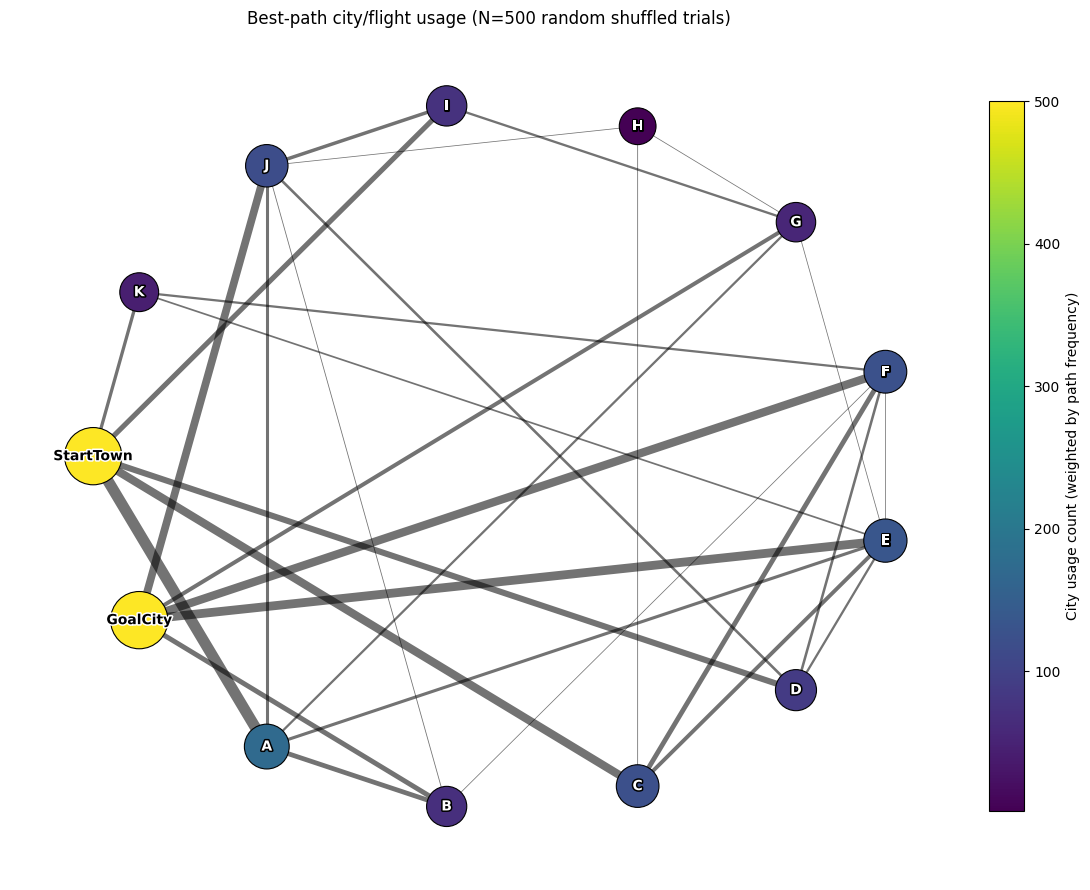

In [5]:

def _rescale(x, out_min, out_max):
    x = np.asarray(x, dtype=float)
    xmin, xmax = np.nanmin(x), np.nanmax(x)
    if np.isclose(xmin, xmax):
        return np.full_like(x, (out_min + out_max) / 2.0)
    return out_min + (x - xmin) * (out_max - out_min) / (xmax - xmin)

def _text_color_for_rgba(rgba):
    r, g, b, _ = rgba
    lum = 0.2126 * r + 0.7152 * g + 0.0722 * b
    return "black" if lum > 0.55 else "white"

def plot_usage_overlay_on_fixed_layout(
    problem,
    summary,
    pos,
    path_col="best_path_tuple",
    freq_col="n_trials",
    undirected_for_counts=True,
    cmap_name="viridis",
    node_size_range=(700, 1700),
    edge_width_range=(0.5, 8.0),
    edge_alpha=0.55,
    unused_edge_alpha=0, #0.15
    unused_edge_width=0, #0.6
    figsize=(11, 9),
):
    # base graph
    G = nx.Graph()
    for u, nbrs in problem.flights.items():
        G.add_node(u)
        for v in nbrs.keys():
            G.add_node(v)
            G.add_edge(u, v)

    # counts from summary
    edge_counts = Counter()
    node_counts = Counter()

    if summary is not None and len(summary) > 0:
        for path, f in zip(summary[path_col], summary[freq_col]):
            f = int(f)
            path = tuple(path)
            for city in path:
                node_counts[city] += f
            for a, b in zip(path[:-1], path[1:]):
                key = tuple(sorted((a, b))) if undirected_for_counts else (a, b)
                edge_counts[key] += f

    for n in G.nodes:
        node_counts.setdefault(n, 0)

    nodes_in_order = list(G.nodes)
    node_vals = np.array([node_counts[n] for n in nodes_in_order], dtype=float)
    node_sizes = _rescale(node_vals, node_size_range[0], node_size_range[1])

    edges_in_order = list(G.edges)
    ecounts = []
    for (u, v) in edges_in_order:
        key = tuple(sorted((u, v))) if undirected_for_counts else (u, v)
        ecounts.append(edge_counts.get(key, 0))
    ecounts = np.array(ecounts, dtype=float)
    edge_widths = _rescale(ecounts, edge_width_range[0], edge_width_range[1])

    fig, ax = plt.subplots(figsize=figsize)

    # draw all edges; unused faint
    used_mask = ecounts > 0
    used_edges = [e for e, m in zip(edges_in_order, used_mask) if m]
    unused_edges = [e for e, m in zip(edges_in_order, used_mask) if not m]

    if unused_edges:
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=unused_edges,
                               width=unused_edge_width, alpha=unused_edge_alpha)
    if used_edges:
        used_widths = [w for w, m in zip(edge_widths, used_mask) if m]
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=used_edges,
                               width=used_widths, alpha=edge_alpha)

    # node colors + labels with adaptive text color
    cmap = mpl.cm.get_cmap(cmap_name)
    vmax = node_vals.max()
    vmin = node_vals.min()
    if np.isclose(vmin, vmax):
        vmax = vmin + 1.0
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    node_facecolors = [cmap(norm(v)) for v in node_vals]

    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=node_sizes,
        node_color=node_facecolors,
        linewidths=0.8,
        edgecolors="black",
    )

    # ---- Draw labels with outline ----
    for n in nodes_in_order:
        rgba = cmap(norm(node_counts[n]))
        txt_color = _text_color_for_rgba(rgba)

        # opposite color for outline
        outline_color = "white" if txt_color == "black" else "black"

        ax.text(
            *pos[n],
            str(n),
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color=txt_color,
            path_effects=[
                pe.Stroke(linewidth=2.2, foreground=outline_color),
                pe.Normal()
            ]
        )

    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("City usage count (weighted by path frequency)")

    ax.set_title("Best-path city/flight usage (N={0} random shuffled trials)".format(n_trials))
    ax.axis("off")
    plt.tight_layout()
    return fig, ax

fig1, ax1 = plot_usage_overlay_on_fixed_layout(problem, summary, pos)
#plt.savefig(os.path.join(figpath, "exp3_shuffletrials_visitfreq"), dpi=300)
plt.show()

### Get each past solution's loss on each trial

In [6]:
# Convert inner lists to tuples because lists are not hashable for Counter
list_of_tuples = [tuple(best_path) for best_path in best_path_trials]
# Count the frequencies of the tuples
best_path_frequencies = Counter(list_of_tuples)
# Print the unique lists and their frequencies
print("Unique lists and their frequencies:")
for unique_list_tuple, frequency in best_path_frequencies.items():
    print(f"{list(unique_list_tuple)}: {frequency}")
# To get the unique lists in a separate list
unique_best_paths = [list(item) for item in best_path_frequencies.keys()]

for problem in trials:
    result = dijkstra_expanded(problem, start, goal, weights)
    best = result.best_loss
    tol = 1e-9
    print("\nPast itinerary optimality check:")
    for itin in unique_best_paths:
        L = itinerary_loss(problem, weights, itin)
        tag = "OPTIMAL" if abs(L - best) <= tol else "not optimal"
        print(f"  {itin}  loss={L:.4f}  -> {tag}")

Unique lists and their frequencies:
['StartTown', 'C', 'F', 'GoalCity']: 67
['StartTown', 'I', 'G', 'GoalCity']: 27
['StartTown', 'K', 'E', 'GoalCity']: 17
['StartTown', 'I', 'J', 'GoalCity']: 46
['StartTown', 'D', 'J', 'GoalCity']: 31
['StartTown', 'A', 'E', 'GoalCity']: 40
['StartTown', 'C', 'E', 'GoalCity']: 52
['StartTown', 'A', 'J', 'GoalCity']: 38
['StartTown', 'D', 'E', 'GoalCity']: 25
['StartTown', 'A', 'B', 'GoalCity']: 67
['StartTown', 'A', 'G', 'GoalCity']: 26
['StartTown', 'K', 'F', 'GoalCity']: 26
['StartTown', 'D', 'F', 'GoalCity']: 31
['StartTown', 'D', 'E', 'F', 'GoalCity']: 1
['StartTown', 'C', 'H', 'J', 'GoalCity']: 1
['StartTown', 'C', 'H', 'G', 'GoalCity']: 1
['StartTown', 'A', 'J', 'B', 'GoalCity']: 1
['StartTown', 'C', 'F', 'B', 'GoalCity']: 1
['StartTown', 'C', 'E', 'G', 'GoalCity']: 1
['StartTown', 'D', 'J', 'B', 'GoalCity']: 1

Past itinerary optimality check:
  ['StartTown', 'C', 'F', 'GoalCity']  loss=1950.0000  -> OPTIMAL
  ['StartTown', 'I', 'G', 'GoalCity'

  ['StartTown', 'I', 'G', 'GoalCity']  loss=5300.0000  -> not optimal
  ['StartTown', 'K', 'E', 'GoalCity']  loss=2550.0000  -> not optimal
  ['StartTown', 'I', 'J', 'GoalCity']  loss=2400.0000  -> not optimal
  ['StartTown', 'D', 'J', 'GoalCity']  loss=2550.0000  -> not optimal
  ['StartTown', 'A', 'E', 'GoalCity']  loss=3150.0000  -> not optimal
  ['StartTown', 'C', 'E', 'GoalCity']  loss=3200.0000  -> not optimal
  ['StartTown', 'A', 'J', 'GoalCity']  loss=2200.0000  -> not optimal
  ['StartTown', 'D', 'E', 'GoalCity']  loss=2500.0000  -> not optimal
  ['StartTown', 'A', 'B', 'GoalCity']  loss=2000.0000  -> OPTIMAL
  ['StartTown', 'A', 'G', 'GoalCity']  loss=2900.0000  -> not optimal
  ['StartTown', 'K', 'F', 'GoalCity']  loss=2000.0000  -> OPTIMAL
  ['StartTown', 'D', 'F', 'GoalCity']  loss=2550.0000  -> not optimal
  ['StartTown', 'D', 'E', 'F', 'GoalCity']  loss=4200.0000  -> not optimal
  ['StartTown', 'C', 'H', 'J', 'GoalCity']  loss=2850.0000  -> not optimal
  ['StartTown', 'C

In [7]:
import pandas as pd
from collections import Counter
from typing import List, Dict, Any, Tuple, Optional


def unique_best_paths_with_counts(best_path_trials: List[List[str]]):
    """
    best_path_trials: list of city-paths (each is a list[str]) e.g. produced per-trial.
    Returns:
      unique_best_paths: list[list[str]] in a stable order
      counts: Counter of tuple(paths)
    """
    list_of_tuples = [tuple(p) for p in best_path_trials]
    counts = Counter(list_of_tuples)

    # Stable order: most frequent first, then lexicographic tie-break
    ordered = sorted(counts.items(), key=lambda kv: (-kv[1], kv[0]))
    unique_best_paths = [list(t) for (t, _) in ordered]
    return unique_best_paths, counts


def _path_colname(itin: List[str], maxlen: int = 6) -> str:
    """
    Human-friendly but deterministic column name for an itinerary.
    If path is long, truncate and include length.
    """
    if len(itin) <= maxlen:
        core = "→".join(itin)
    else:
        core = "→".join(itin[:3]) + "→…→" + "→".join(itin[-2:])
    return f"path[{len(itin)}] {core}"


def build_trial_by_path_loss_df(
    trials: List[Any],                 # List[CovidNavProblem]
    start: str,
    goal: str,
    weights: Any,                      # Weights
    unique_best_paths: List[List[str]],
    tol: float = 1e-9,
    include_optimal_flags: bool = True,
    include_trial_best_loss: bool = True,
    include_trial_best_path: bool = True,
) -> pd.DataFrame:
    """
    Returns a dataframe with one row per trial.
    Columns include:
      - (optional) trial_best_loss
      - (optional) trial_best_path (string)
      - For each itinerary in unique_best_paths:
          loss::<path_colname>
          (optional) is_opt::<path_colname>
    """
    # Precompute colnames
    path_names = [_path_colname(p) for p in unique_best_paths]

    rows: List[Dict[str, Any]] = []

    for t_idx, problem in enumerate(trials):
        result = dijkstra_expanded(problem, start, goal, weights)
        best_loss = result.best_loss

        row: Dict[str, Any] = {"trial": t_idx}

        if include_trial_best_loss:
            row["trial_best_loss"] = float(best_loss)

        if include_trial_best_path:
            # choose one optimal path (if any) to display
            opt_paths = enumerate_optimal_paths(result, start, goal, limit=1)
            if opt_paths:
                chosen = [city for (city, h) in opt_paths[0]]
                row["trial_best_path"] = "→".join(chosen)
            else:
                row["trial_best_path"] = None

        for itin, pname in zip(unique_best_paths, path_names):
            L = itinerary_loss(problem, weights, itin)
            row[f"loss::{pname}"] = float(L)
            if include_optimal_flags:
                row[f"is_opt::{pname}"] = bool(abs(L - best_loss) <= tol)

        rows.append(row)

    df = pd.DataFrame(rows)

    # Nice ordering: metadata first, then loss cols, then flags
    meta_cols = ["trial"]
    if include_trial_best_loss:
        meta_cols.append("trial_best_loss")
    if include_trial_best_path:
        meta_cols.append("trial_best_path")

    loss_cols = [c for c in df.columns if c.startswith("loss::")]
    opt_cols  = [c for c in df.columns if c.startswith("is_opt::")]

    df = df[meta_cols + loss_cols + opt_cols]
    return df



# 1) We already have best_path_trials from earlier runs (e.g., the best path per trial)
unique_best_paths, best_path_frequencies = unique_best_paths_with_counts(best_path_trials)

# 2) Build the per-trial dataframe
df_trials = build_trial_by_path_loss_df(
    trials=trials,
    start=start,
    goal=goal,
    weights=weights,
    unique_best_paths=unique_best_paths,
    tol=1e-9,
    include_optimal_flags=True,
    include_trial_best_loss=True,
    include_trial_best_path=True,
)
df_trials['n_flights_taken_optimal'] = df_trials['trial_best_path'].str.count("→")
df_trials[["trial_best_path","n_flights_taken_optimal"]]

# 3) Inspect
loss_cols = [col for col in df_trials.columns if 'loss::' in col]
isbest_cols = [col for col in df_trials.columns if 'is_opt::' in col]
for col in loss_cols:
    df_trials["lossdiff"+col[4:]] = df_trials[col] - df_trials["trial_best_loss"]
lossdiff_cols = ["lossdiff"+col[4:] for col in loss_cols]
#df_trials.columns

# Sanity check: all trials unique? Then the two printed value should match below.
print(df_trials.shape)
df_new = df_trials[loss_cols].copy()
unique_rows_first = df_trials[~df_new.duplicated()] # Remove entirely duplicate rows
print(unique_rows_first.shape)
# df.to_csv("trial_by_path_losses.csv", index=False)

(500, 64)
(500, 64)


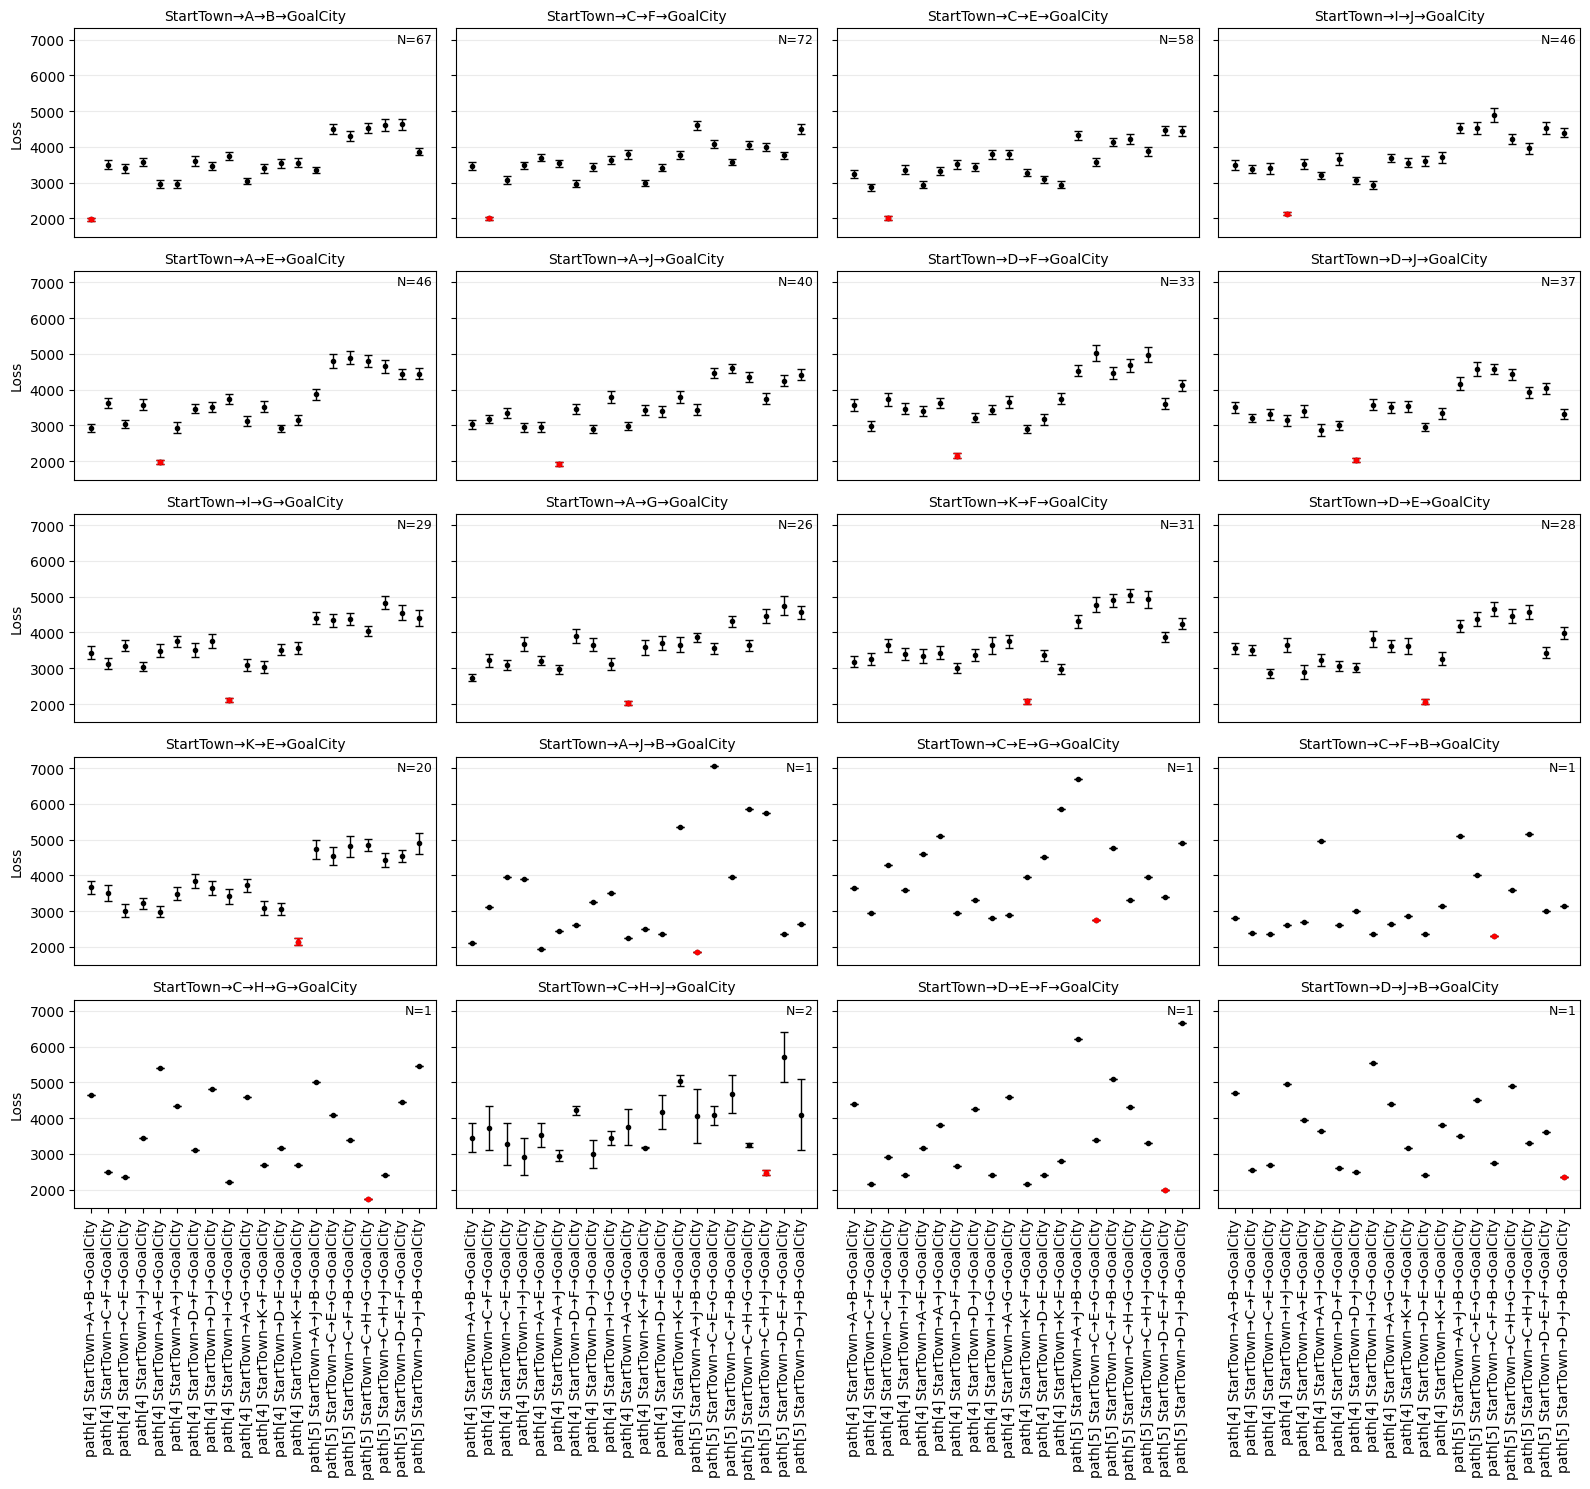

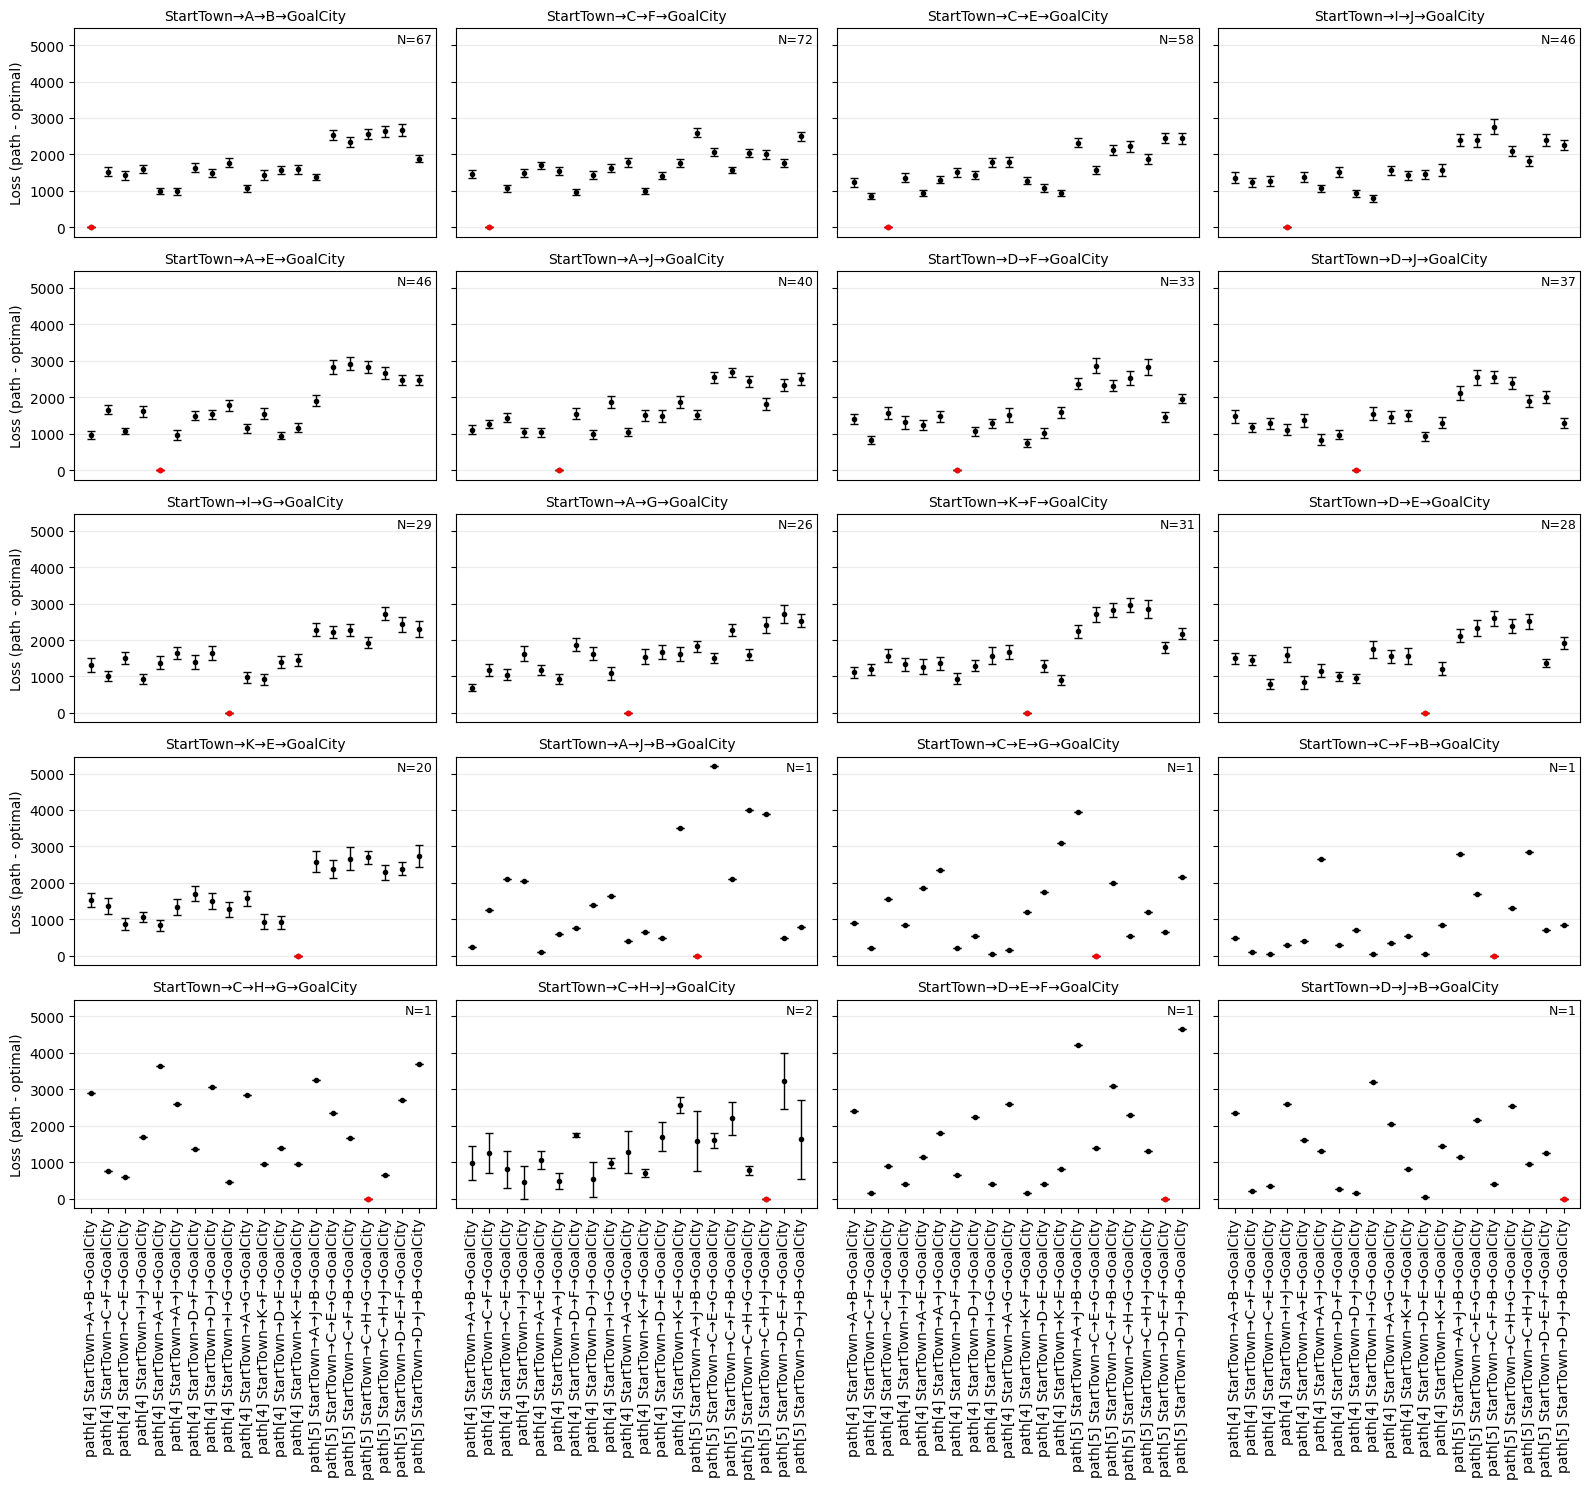

In [8]:
def add_lossdiff_columns(df_trials):
    """
    Convenience helper matching your snippet:

      for col in loss_cols:
          df_trials["lossdiff"+col[4:]] = df_trials[col] - df_trials["trial_best_loss"]

    Returns:
      df_trials (modified in place) and list of losdiff column names
    """
    loss_cols = [c for c in df_trials.columns if c.startswith("loss::")]
    for col in loss_cols:
        df_trials["lossdiff" + col[4:]] = df_trials[col] - df_trials["trial_best_loss"]
    lossdiff_cols = ["lossdiff" + col[4:] for col in loss_cols]
    return df_trials, lossdiff_cols


def plot_conditioned_means_sem(
    df,
    *,
    y_prefix: str = "loss::",          # "loss::" or "lossdiff::" 
    opt_prefix: str = "is_opt::",
    max_cols: int = 4,
    sharey: bool = True,
    figsize_per_subplot: Tuple[float, float] = (4.0, 3.0),
    capsize: float = 3.0,
    rotate_xticks: int = 90,           # vertical labels
    show_only_nonempty: bool = True,   # only subplots where focal path is optimal at least once
):
    """
    For each past path (label), make a subplot containing mean ± SEM of y-values
    across the subset of trials where that focal path is optimal.

    Changes per your request:
      1) No strip/scatter; no subplot titles; instead, color the focal path's errorbar green,
         others black.
      2) Choose y-axis columns via y_prefix (e.g., "loss::" or "lossdiff::").
      3) Only show x-tick labels on the last row; make them vertical.
    """
    # --- identify columns ---
    y_cols = [c for c in df.columns if c.startswith(y_prefix)]
    opt_cols = [c for c in df.columns if c.startswith(opt_prefix)]

    if not y_cols:
        raise ValueError(f"No columns found with y_prefix='{y_prefix}'.")
    if not opt_cols:
        raise ValueError(f"No columns found with opt_prefix='{opt_prefix}'.")
        
    if(y_prefix=="loss::"):
        y_lab = "Loss"
    elif(y_prefix=="lossdiff::"):
        y_lab = "Loss (path - optimal)"

    # labels are the suffix after the prefix; require both y and opt for that suffix
    y_labels = [c[len(y_prefix):] for c in y_cols]
    opt_labels = [c[len(opt_prefix):] for c in opt_cols]

    label_to_y = {lab: f"{y_prefix}{lab}" for lab in y_labels}
    label_to_opt = {lab: f"{opt_prefix}{lab}" for lab in opt_labels}

    labels = [lab for lab in y_labels if lab in label_to_opt]
    if not labels:
        raise ValueError("No matching labels between y and opt columns. "
                         "Ensure suffixes match (e.g., loss::<X> and is_opt::<X>).")

    if show_only_nonempty:
        labels = [lab for lab in labels if df[label_to_opt[lab]].fillna(False).any()]
        if not labels:
            raise ValueError("No focal paths have any optimal trials (or is_opt columns are all False).")

    n_sub = len(labels)
    ncols = min(max_cols, n_sub)
    nrows = int(np.ceil(n_sub / ncols))

    fig_w = figsize_per_subplot[0] * ncols
    fig_h = figsize_per_subplot[1] * nrows
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), sharey=sharey)
    axes = np.array(axes).reshape(-1)

    # x positions correspond to ALL labels (same order everywhere)
    x = np.arange(len(labels))

    for ax_i, (ax, focal_lab) in enumerate(zip(axes, labels)):
        opt_mask = df[label_to_opt[focal_lab]].fillna(False).to_numpy(dtype=bool)
        sub = df.loc[opt_mask, :]
        

        n_trials = len(sub)
        if n_trials == 0:
            ax.axis("off")
            continue

        # title
        ax.set_title(focal_lab[8:], fontsize=10)
        
        means = np.zeros(len(labels), dtype=float)
        sems = np.zeros(len(labels), dtype=float)

        for j, lab in enumerate(labels):
            vals = sub[label_to_y[lab]].to_numpy(dtype=float)
            means[j] = float(np.mean(vals))
            if len(vals) >= 2:
                sems[j] = float(np.std(vals, ddof=1) / np.sqrt(len(vals)))
            else:
                sems[j] = 0.0

        # Draw black errorbars for all, then overlay the focal as green
        ax.errorbar(
            x, means, yerr=sems,
            fmt=".",
            capsize=capsize,
            elinewidth=1.0,
            color="black",
        )

        # Overlay focal in green (point + errorbar)
        j0 = labels.index(focal_lab)
        ax.errorbar(
            [x[j0]], [means[j0]], yerr=[sems[j0]],
            fmt=".",
            capsize=capsize,
            elinewidth=1.8,
            color="red",
        )

        # Light y-grid only
        ax.grid(True, axis="y", alpha=0.25)

        # X ticks: only last row shows labels
        ax.set_xticks(x)
        is_last_row = (ax_i // ncols) == (nrows - 1)
        if is_last_row:
            ax.set_xticklabels(labels, rotation=rotate_xticks, ha="center", va="top")
        else:
            ax.set_xticklabels([])
            ax.tick_params(axis="x", length=0)
            
        is_first_col = (ax_i%ncols)==0
        if(is_first_col):
            ax.set_ylabel(y_lab)

        # Optional: annotate N in a subtle corner (no title)
        ax.text(
            0.99, 0.98, f"N={n_trials}",
            ha="right", va="top",
            transform=ax.transAxes,
            fontsize=9,
        )

    # Hide unused axes
    for ax in axes[n_sub:]:
        ax.axis("off")
    fig.tight_layout()


# Plot raw losses:
plot_conditioned_means_sem(df_trials, y_prefix="loss::", max_cols=4)
#plt.savefig(os.path.join(figpath, "exp3_shuffletrials_pathloss"), dpi=300)
plt.show()

# # Plot loss differences:
plot_conditioned_means_sem(df_trials, y_prefix="lossdiff::", max_cols=4)
#plt.savefig(os.path.join(figpath, "exp3_shuffletrials_pathlossdiff"), dpi=300)
plt.show()

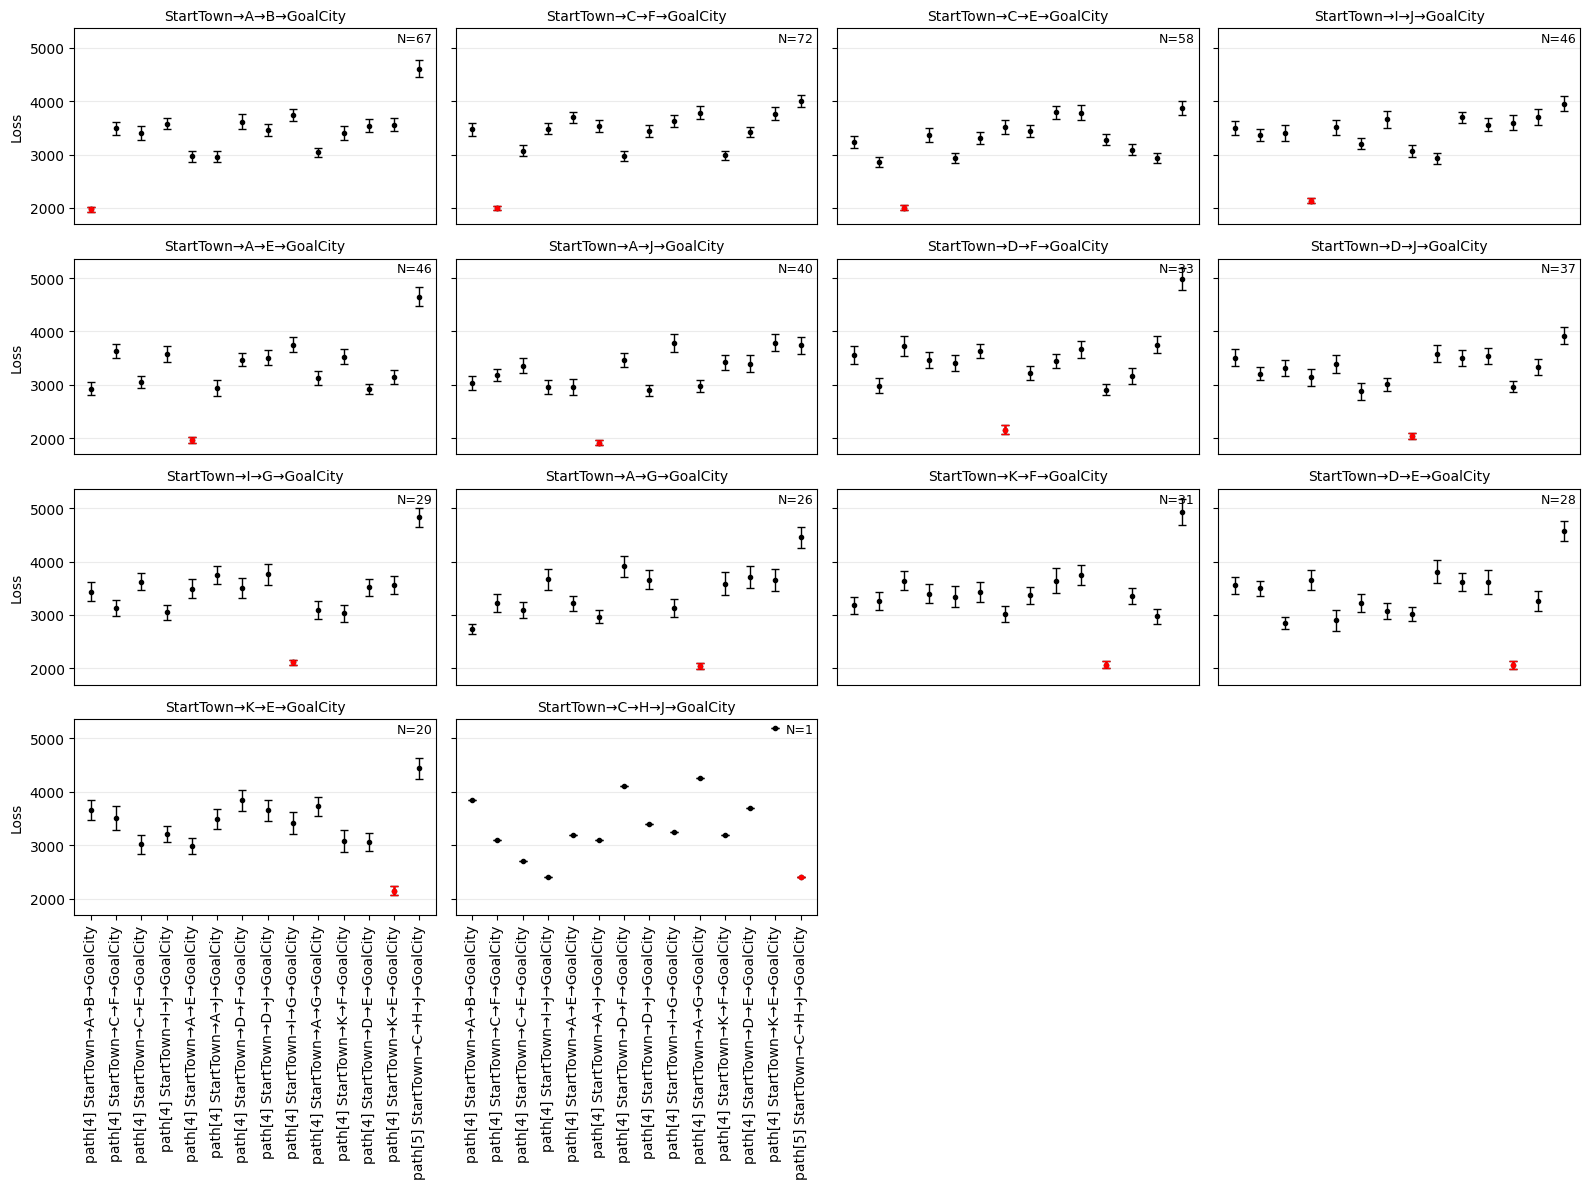

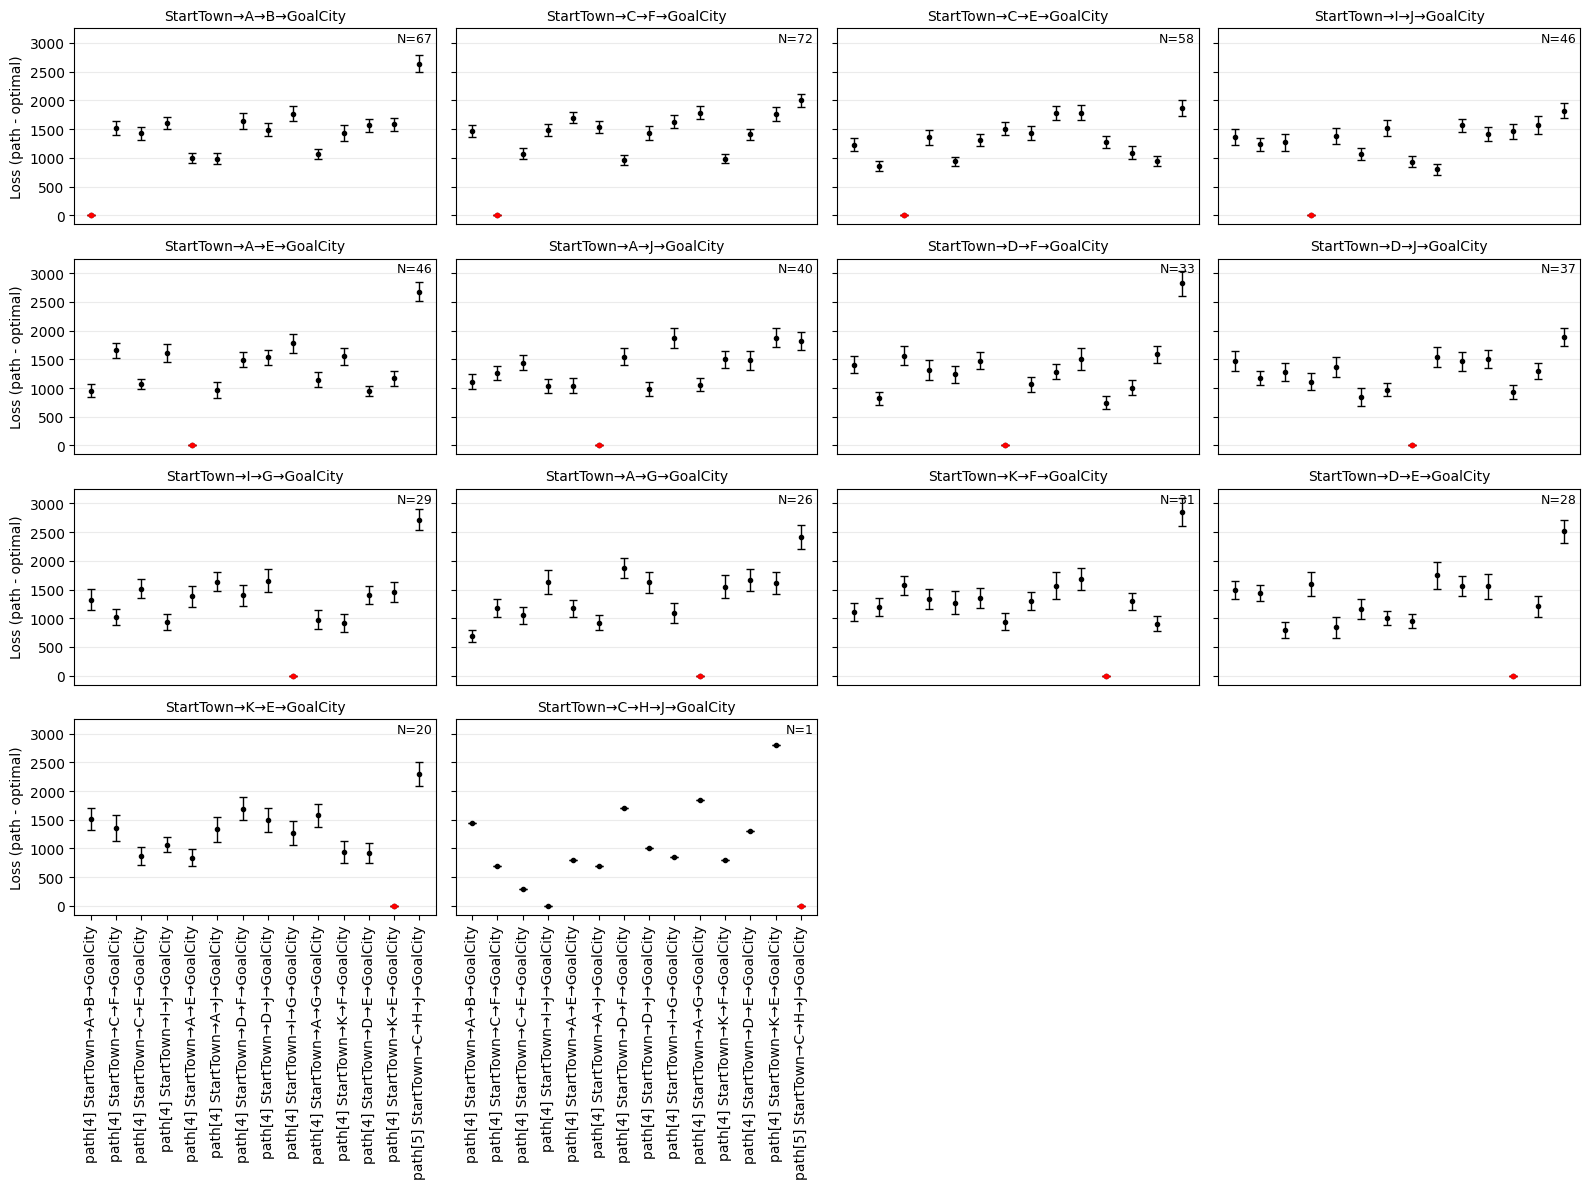

In [9]:
# Only visualize 3-step best solutions
df_trials_3steps = df_trials.copy()
df_trials_3steps = df_trials_3steps[df_trials_3steps["n_flights_taken_optimal"]==3]
loss_cols_3steps = [loss_col for loss_col in loss_cols if "path[4]" in loss_col]

# Plot raw losses:
plot_conditioned_means_sem(df_trials_3steps, y_prefix="loss::", max_cols=4)
#plt.savefig(os.path.join(figpath, "exp3_shuffletrials_pathloss_3steps"), dpi=300)
plt.show()

# # Plot loss differences:
plot_conditioned_means_sem(df_trials_3steps, y_prefix="lossdiff::", max_cols=4)
#plt.savefig(os.path.join(figpath, "exp3_shuffletrials_pathlossdiff_3steps"), dpi=300)
plt.show()

In [10]:
df_trials_3steps.to_csv(os.path.join("..","experiment","exp3_problems","problems_bundle_noqcostrule.csv"), index=False)

In [11]:
df_trials_3steps[lossdiff_cols].mean() + 3*df_trials_3steps[lossdiff_cols].std(ddof=1)

lossdiff::path[4] StartTown→A→B→GoalCity      3933.407233
lossdiff::path[4] StartTown→C→F→GoalCity      3723.587544
lossdiff::path[4] StartTown→C→E→GoalCity      3921.160248
lossdiff::path[4] StartTown→I→J→GoalCity      4260.016624
lossdiff::path[4] StartTown→A→E→GoalCity      3884.811707
lossdiff::path[4] StartTown→A→J→GoalCity      3899.933103
lossdiff::path[4] StartTown→D→F→GoalCity      4199.521457
lossdiff::path[4] StartTown→D→J→GoalCity      4072.408862
lossdiff::path[4] StartTown→I→G→GoalCity      4633.831196
lossdiff::path[4] StartTown→A→G→GoalCity      4338.632390
lossdiff::path[4] StartTown→K→F→GoalCity      4084.160487
lossdiff::path[4] StartTown→D→E→GoalCity      3953.910224
lossdiff::path[4] StartTown→K→E→GoalCity      4308.147375
lossdiff::path[5] StartTown→A→J→B→GoalCity    5271.374751
lossdiff::path[5] StartTown→C→E→G→GoalCity    5700.037225
lossdiff::path[5] StartTown→C→F→B→GoalCity    5695.538946
lossdiff::path[5] StartTown→C→H→G→GoalCity    5538.512219
lossdiff::path

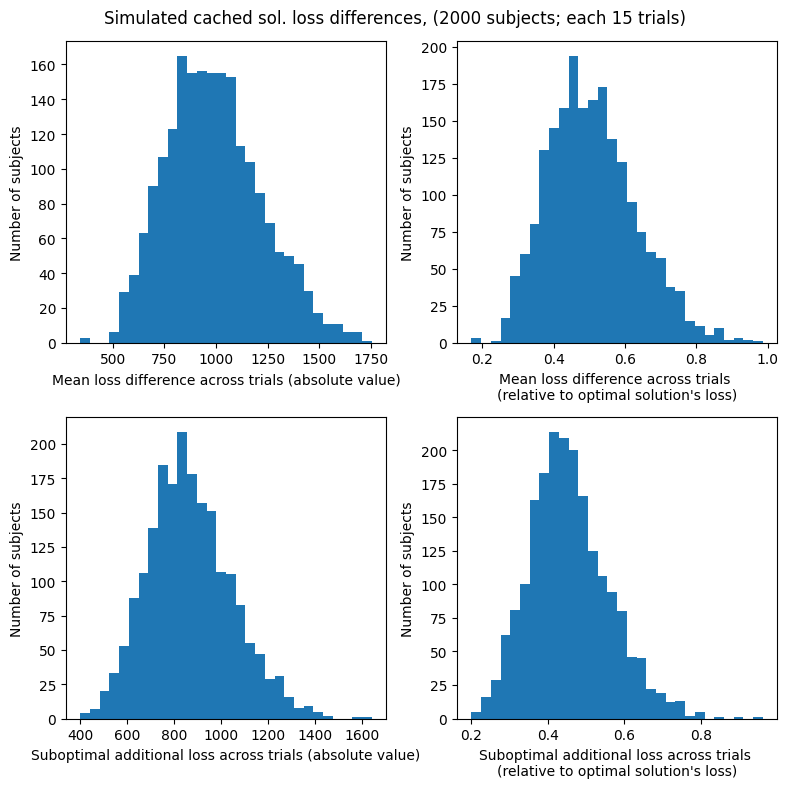

In [12]:

def simulate_loss_differences(
    df,
    n_trials_per_subject=7,
    n_subjects=1000,
    use_abs=True,
    random_state=None
):
    rng = np.random.default_rng(random_state)

    # loss columns only
    #loss_cols = [c for c in df.columns if c.startswith("loss::")]
    # Limit ourselves to the 10 three-step solutions, not four-step solutions or more.
    loss_cols = ["loss::path[4] "+col for col in np.unique(df_trials_3steps["trial_best_path"])]

    # Parse:
    #   "loss::path[4] StartTown→HubCity→SafeTown→GoalCity"
    # into raw path:
    #   "StartTown→HubCity→SafeTown→GoalCity"
    col_to_path = {}
    for c in loss_cols:
        s = c[len("loss::"):]                  # remove "loss::"
        s = re.sub(r"^path\[\d+\]\s*", "", s)  # remove leading "path[n] "
        col_to_path[c] = s

    unique_paths = sorted(set(col_to_path.values()))

    # reverse map: raw path -> column name
    path_to_col = {path: col for col, path in col_to_path.items()}

    subject_rawloss_means = []
    subject_means = []
    subject_means_prop = []
    subject_pairs = []
    subject_means_frombest = []
    subject_means_frombest_prop = []

    for _ in range(n_subjects):
        # 1) sample two candidate solutions
        p1, p2 = rng.choice(unique_paths, size=2, replace=False)

        col1 = path_to_col[p1]
        col2 = path_to_col[p2]

        # 2) keep only trials where BOTH trained paths are suboptimal
#         mask = (df["trial_best_path"] != p1) & (df["trial_best_path"] != p2)

        # The code below is correct, because there are trials where there are multiple optimal paths---and "trial_best_path" only records one of them.
        for better_sol in [0,1]:
            if(better_sol==0):
                mask_cond = (df["loss::path[4] "+p1]<df["loss::path[4] "+p2])
            else:
                mask_cond = (df["loss::path[4] "+p1]>df["loss::path[4] "+p2])
            mask = (df["is_opt::path[4] "+p1]==False) & (df["is_opt::path[4] "+p2]==False) & mask_cond
            eligible = df.loc[mask]
            if len(eligible) < (n_trials_per_subject//2):
                print("Failed to find enough trials.")
                continue
            sampled_temp = eligible.sample(
                n=n_trials_per_subject//2,
                replace=False,
                random_state=int(rng.integers(0, 2**31 - 1))
            )
            if(better_sol==0):
                sampled = sampled_temp
            else:
                sampled = pd.concat([sampled, sampled_temp], ignore_index=True)
            sampled = sampled.sample(frac=1)
            
        # 3) compute trialwise loss differences
        # raw_losses = 0.5*(sampled[col1] + sampled[col2])
        raw_losses = np.minimum(sampled[col1], sampled[col2])  # Assume that people reuse the better sol.
        diffs = sampled[col1] - sampled[col2]
        # diffs_frombest = 0.5*((sampled[col1] - sampled["trial_best_loss"]) + (sampled[col2] - sampled["trial_best_loss"]))
        diffs_frombest = np.minimum((sampled[col1] - sampled["trial_best_loss"]), (sampled[col2] - sampled["trial_best_loss"])) # Assume that people reuse the better sol.

        if use_abs:
            diffs = diffs.abs()
            diffs_frombest = diffs_frombest.abs()

        # 4) average across sampled trials
        subject_rawloss_means.append(raw_losses.mean())
        subject_means.append(diffs.mean())
        subject_means_prop.append((diffs/sampled["trial_best_loss"].to_numpy()).mean())
        subject_means_frombest.append(diffs_frombest.mean())
        subject_means_frombest_prop.append((diffs_frombest/sampled["trial_best_loss"].to_numpy()).mean())
        subject_pairs.append((p1, p2))

    subject_rawloss_means = np.asarray(subject_rawloss_means)
    subject_means = np.asarray(subject_means)
    subject_means_frombest = np.asarray(subject_means_frombest)

    # 5) histogram across subjects
    fig, ax = plt.subplots(2,2,figsize=(8,8))
    ax[0,0].hist(subject_means, bins=30)
    ax[0,0].set_xlabel("Mean loss difference across trials (absolute value)")
    ax[0,0].set_ylabel("Number of subjects")
    ax[0,1].hist(subject_means_prop, bins=30)
    ax[0,1].set_xlabel("Mean loss difference across trials \n(relative to optimal solution's loss)")
    
    ax[0,1].set_ylabel("Number of subjects")
    ax[1,0].hist(subject_means_frombest, bins=30)
    ax[1,0].set_xlabel("Suboptimal additional loss across trials (absolute value)")
    ax[1,0].set_ylabel("Number of subjects")
    ax[1,1].hist(subject_means_frombest_prop, bins=30)
    ax[1,1].set_xlabel("Suboptimal additional loss across trials \n(relative to optimal solution's loss)")
    ax[1,1].set_ylabel("Number of subjects")
    
    fig.suptitle("Simulated cached sol. loss differences, ({0} subjects; each {1} trials)".format(n_subjects, n_trials_per_subject))
    plt.tight_layout()

    return pd.DataFrame({
        "path1": [p[0] for p in subject_pairs],
        "path2": [p[1] for p in subject_pairs],
        "mean_loss": subject_rawloss_means,
        "mean_loss_difference": subject_means,
        "mean_loss_frombest": subject_means_frombest,
    })


subject_diffs = simulate_loss_differences(
    df_trials_3steps,
    n_trials_per_subject=15,
    n_subjects=2000,
    use_abs=True,
    random_state=0
)
plt.show()

Mean bonus for random selection of 3-step routes:  1.3326220143229706
Mean bonus for selecting the better of the two cached sols:  1.4590270408163264


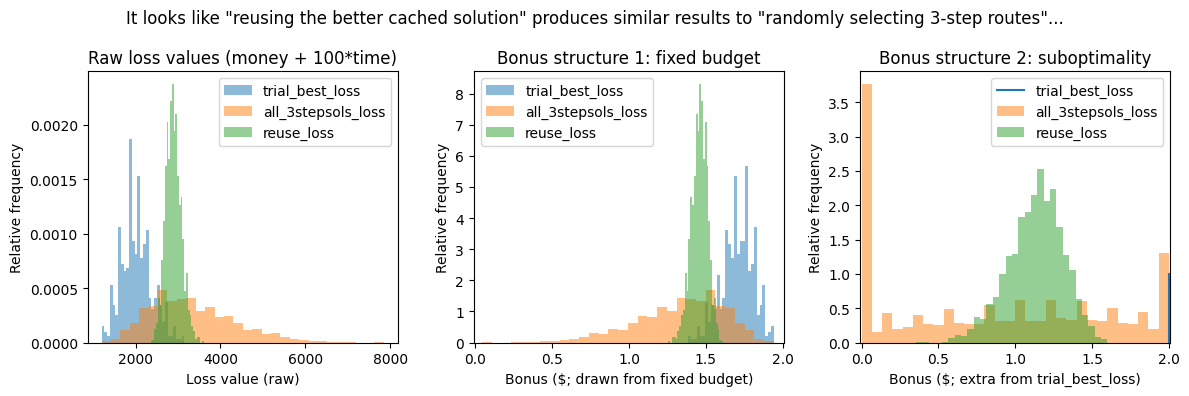

In [18]:
fig,ax = plt.subplots(1,3, figsize=(12,4))
trial_best_losses = df_trials_3steps["trial_best_loss"]
all_3step_losses = df_trials_3steps[loss_cols[0:-6]].to_numpy()
all_3step_lossdiffs = df_trials_3steps[lossdiff_cols[0:-6]].to_numpy()
bonus_max_dollars = 2

bonus_baseline1 = 5000
bonus_baseline1_min = -3000
bonus_baseline1_max = 4000
bonus1_fun = lambda x: np.minimum(np.maximum(bonus_max_dollars * (bonus_baseline1 - x-bonus_baseline1_min)/(bonus_baseline1_max-bonus_baseline1_min),0),bonus_max_dollars)

bonus2_slope = 0.001
bonus2_fun = lambda x: np.maximum(bonus_max_dollars - bonus2_slope*x, 0)

ax[0].hist(trial_best_losses, bins=30, alpha=0.5, density=True, label="trial_best_loss")
ax[0].hist(all_3step_losses.flatten(), bins=30, alpha=0.5, density=True, label="all_3stepsols_loss")
ax[0].hist(subject_diffs["mean_loss"].to_numpy(), bins=30, alpha=0.5, density=True, color="C2", label="reuse_loss")
ax[0].legend()
ax[0].set_xlabel("Loss value (raw)")
ax[0].set_ylabel("Relative frequency")
ax[0].set_title("Raw loss values (money + 100*time)")

ax[1].hist(bonus1_fun(trial_best_losses), bins=30, alpha=0.5, density=True, label="trial_best_loss")
ax[1].hist(bonus1_fun(all_3step_losses.flatten()), bins=30, alpha=0.5, density=True, label="all_3stepsols_loss")
ax[1].hist(bonus1_fun(subject_diffs["mean_loss"].to_numpy()), bins=30, alpha=0.5, density=True, color="C2", label="reuse_loss")
ax[1].legend()
ax[1].set_xlabel("Bonus ($; drawn from fixed budget)")
ax[1].set_ylabel("Relative frequency")
ax[1].set_title("Bonus structure 1: fixed budget")
print("Mean bonus for random selection of 3-step routes: ", np.mean(bonus1_fun(all_3step_losses.flatten())))
print("Mean bonus for selecting the better of the two cached sols: ", np.mean(bonus1_fun(subject_diffs["mean_loss"].to_numpy())))

ax[2].plot([bonus_max_dollars,bonus_max_dollars],[0,1], color="C0", label="trial_best_loss")
ax[2].hist(bonus2_fun(all_3step_lossdiffs.flatten()), bins=30, alpha=0.5, density=True, color="C1", label="all_3stepsols_loss")
ax[2].hist(bonus2_fun(subject_diffs["mean_loss_frombest"].to_numpy()), bins=30, alpha=0.5, density=True, color="C2", label="reuse_loss")
ax[2].legend()
ax[2].set_xlabel("Bonus ($; extra from trial_best_loss)")
ax[2].set_ylabel("Relative frequency")
ax[2].set_title("Bonus structure 2: suboptimality")

for col in [1,2]:
    ax[col].set_xlim(0-0.01, bonus_max_dollars+0.01)

fig.suptitle("It looks like \"reusing the better cached solution\" produces similar results to \"randomly selecting 3-step routes\"...")
fig.tight_layout()
plt.show()

## Convert problem and pos objects to JsPsych-compatible files

In [16]:
import json
import numpy as np


def export_problem_for_jspsych(
    problem,
    pos,
    ring,
    start,
    goal,
    best_path=None,
    node_rule_text=None,
    svg_width=700,
    svg_height=700,
    radius=260,
    center_x=None,
    center_y=None,
):
    """
    Convert Python CovidNavProblem + NetworkX shell pos
    into JSON-ready format for jsPsych plugin.
    """

    if center_x is None:
        center_x = svg_width / 2
    if center_y is None:
        center_y = svg_height / 2

    # ----------------------------------------------------
    # 1) Nodes
    # ----------------------------------------------------
    nodes = []
    for city_name, city_obj in problem.cities.items():

        rule_str = ""
        if node_rule_text is not None:
            rule_str = node_rule_text.get(city_name, "")
        else:
            # fallback if no pretty rule text provided
            rule_str = "custom_rule"
            

        nodes.append({
            "id": city_name,
            "virus": float(city_obj.virus),
            "q_cost_per_day": float(city_obj.q_cost_per_day),
            "rule_text": rule_str,
        })

    # ----------------------------------------------------
    # 2) Edges (deduplicate undirected graph)
    # ----------------------------------------------------
    seen = set()
    edges = []

    for u, nbrs in problem.flights.items():
        for v, flight in nbrs.items():

            key = tuple(sorted((u, v)))
            if key in seen:
                continue
            seen.add(key)

            edges.append({
                "u": u,
                "v": v,
                "duration": float(flight.duration),
                "cost": float(flight.cost),
            })

    # ----------------------------------------------------
    # 3) Layout conversion
    # NetworkX shell layout is in [-1, 1] range.
    # We convert to SVG coordinates.
    # ----------------------------------------------------
    node_pos = {}
    
    if(pos is not None):

        for city, xy in pos.items():

            # pos values are numpy arrays
            x_norm = float(xy[0])
            y_norm = float(xy[1])

            # Convert from [-1,1] circle to SVG pixel coordinates
            x_svg = center_x + radius * x_norm
            y_svg = center_y + radius * y_norm

            node_pos[city] = {
                "x": x_svg,
                "y": y_svg,
            }

    # ----------------------------------------------------
    # 4) Final JSON object
    # ----------------------------------------------------
    export_obj = {
        "problem": {
            "start": start,
            "goal": goal,
            "nodes": nodes,
            "edges": edges,
            "best_path": best_path if best_path is not None else [],
            "tracked": list(problem.tracked) if hasattr(problem, "tracked") else [],
        },
        "layout": {
            "node_pos": node_pos,
            "ring_order": ring
        }
        
    }

    return export_obj

In [17]:
export_data = export_problem_for_jspsych(
    problem=problem,
    pos=None,
    ring=list(pos.keys()),
    start=start,
    goal=goal,
    best_path=best_path,
    node_rule_text=node_rule_text,
)

# with open(os.path.join(exppath,"problem_001.json"), "w") as f:
#     json.dump(export_data, f, indent=2)

In [18]:
import json
from pathlib import Path
def write_js_bundle(objs, out_js_path, var_name="COVID_PROBLEMS"):
    """
    objs can be:
      - a list of dicts  -> bundled as array
      - a single dict    -> wrapped into [dict] and bundled as array
    """
    if isinstance(objs, dict):
        objs = [objs]
    elif not isinstance(objs, (list, tuple)):
        raise TypeError(f"objs must be dict or list/tuple, got {type(objs)}")

    payload = json.dumps(list(objs), ensure_ascii=False)
    js = f"window.{var_name} = {payload};\n"
    Path(out_js_path).write_text(js, encoding="utf-8")

In [19]:
# -------------------------
# Store JSON for the 500 trials generated (same seed must be used as before!)
# -------------------------
base = make_problem()
n_trials = 500

trials = generate_shuffled_trials(
    base,
    N=n_trials,
    seed=123,
    mode="within_feature",  # or "bundle"
    shuffle_quarantine_days=True,
    shuffle_city_virus=False, # True
    shuffle_city_qcost=False, # False
    shuffle_flight_cost=True,
    shuffle_flight_duration=False, # Realistically, this should be identical; but we can vary if needed.
    enforce_unique=True, # Don't resample the same trial multiple times
    reject_redundant_quarantine=True, # Make sure the quarantine rules make sense---base rule #days different from all special clauses
    exclude_cities=[],            # keep their virus/qcost and quarantine-day params fixed
    #exclude_edges=[("StartTown", "MetroB")],  # keep these flights fixed; if changed to empty, then 2-step solution would usually be most optimal

)

export_objs = []

# # Solve one trial

weights = Weights(w_time=100, w_cost=1, w_exposure=0) # 4
start, goal = "StartTown", "GoalCity"
best_losses = []
best_path_trials = []
for problem_idx, problem in enumerate(trials):
    result = dijkstra_expanded(problem, start, goal, weights)
    opt_paths = enumerate_optimal_paths(result, start, goal, limit=20)
    best_path = [city for (city, h) in opt_paths[0]]  # pick one optimal itinerary
    best_losses.append(result.best_loss)
    best_path_trials.append(best_path)

    print(np.round(result.best_loss,1), [[c for c,h in p] for p in opt_paths])

#     # 3) Draw the graph with the optimal path highlighted
    node_rule_text = generate_node_rule_text(problem, multiline=True)
    
    export_objs.append(export_problem_for_jspsych(
    problem=problem,
    pos=None, # No need to store pos; not used in JsPsych anyway. 
    ring=list(pos.keys()),
    start=start,
    goal=goal,
    best_path=best_path,
    node_rule_text=node_rule_text,
    ),
)
#     draw_problem_graph(problem, start=start, goal=goal, optimal_city_path=best_path, node_rule_text=node_rule_text, 
#                        figsize=(15,15),    
#                        layout="shell",          # "spring" | "kamada_kawai" | "shell"
#                        seed=0,)
#     plt.savefig(os.path.join(figpath, "exp3_shuffletrials_"+str(problem_idx)), dpi=300)
#     plt.show()

write_js_bundle(export_objs, os.path.join(exppath,"problems_bundle_noqcostrule.js"), var_name="COVID_PROBLEMS")

1950.0 [['StartTown', 'C', 'F', 'GoalCity']]
1850.0 [['StartTown', 'C', 'F', 'GoalCity']]
1750.0 [['StartTown', 'I', 'G', 'GoalCity']]
2900.0 [['StartTown', 'K', 'E', 'GoalCity']]
2100.0 [['StartTown', 'I', 'J', 'GoalCity']]
2100.0 [['StartTown', 'I', 'G', 'GoalCity']]
2000.0 [['StartTown', 'I', 'G', 'GoalCity']]
1750.0 [['StartTown', 'C', 'F', 'GoalCity']]
1200.0 [['StartTown', 'D', 'J', 'GoalCity']]
2200.0 [['StartTown', 'I', 'J', 'GoalCity']]
1700.0 [['StartTown', 'A', 'E', 'GoalCity']]
2350.0 [['StartTown', 'C', 'E', 'GoalCity']]
2350.0 [['StartTown', 'I', 'J', 'GoalCity']]
2650.0 [['StartTown', 'C', 'E', 'GoalCity']]
2050.0 [['StartTown', 'C', 'F', 'GoalCity']]
2200.0 [['StartTown', 'A', 'J', 'GoalCity']]
1900.0 [['StartTown', 'D', 'E', 'GoalCity'], ['StartTown', 'K', 'F', 'GoalCity']]
1450.0 [['StartTown', 'C', 'E', 'GoalCity']]
2200.0 [['StartTown', 'I', 'G', 'GoalCity']]
2000.0 [['StartTown', 'A', 'B', 'GoalCity']]
1750.0 [['StartTown', 'D', 'J', 'GoalCity']]
1800.0 [['StartTow